# Loading libraries and setting constants

Because of the absence of public labeled dataset for recognition of patterns on graph, I will recieve and process OHLCV metric from official stock exchange.
Initially I will download data and label it.

In [1]:
!pip install ccxt pandas mplfinance
!pip install git+https://github.com/keithorange/PatternPy.git
!pip install boto3

  Cloning https://github.com/keithorange/PatternPy.git to /tmp/pip-req-build-g9ri1axg
  Running command git clone --filter=blob:none --quiet https://github.com/keithorange/PatternPy.git /tmp/pip-req-build-g9ri1axg
  Resolved https://github.com/keithorange/PatternPy.git to commit 2b1f29b17986acafffeb32c83e772417d540c100
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import ccxt
import pandas as pd
from datetime import datetime
import time
import math
from google.colab import drive
import os
import sys
import boto3
from google.colab import userdata

import numpy as np
from scipy.signal import find_peaks
from tqdm import tqdm
from tqdm.auto import tqdm
from tqdm.notebook import tqdm
import random
import mplfinance as mpf
from scipy.stats import linregress
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import xgboost as xgb
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import time
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.metrics import auc, precision_recall_curve, average_precision_score, make_scorer
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import TimeSeriesSplit
import joblib
import json
import subprocess

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
symbols = [
    'BTC/USDT', 'ETH/USDT', 'SOL/USDT', 'BNB/USDT', 'XRP/USDT',
    'ADA/USDT', 'DOT/USDT', 'LINK/USDT', 'AVAX/USDT', 'DOGE/USDT',
    'NEAR/USDT', 'ATOM/USDT', 'LTC/USDT', 'PEPE/USDT',
    'SHIB/USDT', 'FET/USDT', 'SUI/USDT', 'APT/USDT', 'OP/USDT',
    'ARB/USDT', 'RENDER/USDT', 'INJ/USDT', 'TIA/USDT'
]
pattern_length = 50
cooldown_jump = int(pattern_length * 0.33)
normal_step = 2

In [4]:
def get_optimal_device():
    """
    Проверяет наличие видеокарты NVIDIA в системе.
    Возвращает 'cuda' если доступно, иначе 'cpu'.
    """
    try:
        # Пытаемся вызвать системную утилиту драйвера видеокарты
        subprocess.check_output('nvidia-smi')
        print("🟢 Ура! Обнаружен GPU (CUDA). Включаем турборежим.")
        return 'cuda'
    except Exception:
        print("🟡 GPU не найден или недоступен. Откатываемся на CPU (процессор).")
        return 'cpu'

# Определяем устройство для всей дальнейшей работы
ACTIVE_DEVICE = get_optimal_device()

🟢 Ура! Обнаружен GPU (CUDA). Включаем турборежим.


In [5]:
# Константы и кодирование меток
TARGET_MAP = {'HS': 1, 'inv-HS': 2, 0: 0, 1: 1, 2: 2}
CLASS_NAMES = {0: 'Noise', 1: 'Classic H&S', 2: 'Inverse H&S'}
RANDOM_STATE = 42

def encode_target(series: pd.Series) -> pd.Series:
    return series.map(TARGET_MAP).fillna(0).astype(int)


# Getting data from stock exchange

In [ ]:
# Reverting to HTX as it has proven to be stable and reliable in your local environment
exchange = ccxt.htx({'enableRateLimit': True})
timeframe = '5m'
limit = 1000
print("🔄 Loading active market profiles from HTX...")
exchange.load_markets()

all_data = {}
end_time = exchange.milliseconds()
total_string_cnt = 0

global_start_time = exchange.parse8601('2018-01-01T00:00:00Z')

print("📁 STARTING AUTOMATED HISTORICAL DOWNLOAD FROM HTX (ENGLISH LOGS)...")

for symbol in symbols:
    if symbol not in exchange.markets:
        print(f"❌ Skipping {symbol}: This market symbol does not exist on HTX.\n")
        continue

    print(f"Initializing data collection sequence for {symbol}...")
    coin_candles = []
    current_since = global_start_time

    # Progress bar now tracks individual candles instead of abstract batches
    with tqdm(total=None, desc=f"Scanning {symbol}", unit=" candle", leave=False) as pbar:
        while current_since < end_time:
            try:
                ohlcv = exchange.fetch_ohlcv(symbol, timeframe, current_since, limit)

                if not ohlcv or len(ohlcv) == 0:
                    if len(coin_candles) == 0:
                        current_since += 30 * 24 * 60 * 60 * 1000
                        continue
                    else:
                        break

                coin_candles.extend(ohlcv)

                last_candle_time = ohlcv[-1][0]
                if last_candle_time == current_since:
                    current_since += 5 * 60 * 1000
                else:
                    current_since = last_candle_time + 1

                pbar.update(len(ohlcv))
                time.sleep(0.05)

            except Exception as e:
                print(f"\n⚠️ API Connectivity notice for {symbol}: {e}. Re-engaging in 5 seconds...")
                time.sleep(5)

        if len(coin_candles) < 100:
            print(f"❌ Aborting sequence for {symbol} due to insufficient row volume.\n")
            continue

    df = pd.DataFrame(coin_candles, columns=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df["Datetime"] = pd.to_datetime(df["Timestamp"], unit="ms")

    df.drop_duplicates(subset=['Timestamp'], inplace=True)

    df.set_index("Datetime", inplace=True)
    df.drop("Timestamp", axis=1, inplace=True)
    df.sort_index(inplace=True)

    all_data[symbol] = df
    total_string_cnt += len(df)
    print(f"✅ {symbol} successfully compiled. Rows: {len(df)} | Cumulative matrix: {total_string_cnt} lines\n")

In [ ]:
raw_output_folder = '/content/drive/MyDrive/Crypto_Raw_Data'
os.makedirs(raw_output_folder, exist_ok=True)

print("Saving raw data")
for symbol, df in all_data.items():
    clean_name = symbol.replace('/', '_') + '_raw.csv'
    path = f'{raw_output_folder}/{clean_name}'
    df.to_csv(path, index=True)
    print(f"Saved: {path}")

In [ ]:
raw_input_folder = '/content/drive/MyDrive/Crypto_Raw_Data'
all_data = {}

print("Downloading raw data from disk")
for symbol in symbols:
    clean_name = symbol.replace('/', '_') + '_raw.csv'
    path = f'{raw_input_folder}/{clean_name}'
    if os.path.exists(path):
        all_data[symbol] = pd.read_csv(path, index_col=0, parse_dates=True)
        print(f"Data: {symbol} ({len(all_data[symbol])} строк)")

In [ ]:
#tmp
raw_input_folder = '/content/drive/MyDrive/Crypto_Raw_Data'
test_all_data = {}

print("Downloading raw data from disk")
for symbol in symbols:
    clean_name = symbol.replace('/', '_') + '_raw.csv'
    path = f'{raw_input_folder}/{clean_name}'
    if os.path.exists(path):
        test_all_data[symbol] = pd.read_csv(path, index_col=0, parse_dates=True)
        print(f"Data: {symbol} ({len(test_all_data[symbol])} строк)")

In [ ]:
test_all_data = {}
for symbol, df in all_data.items():
    test_all_data[symbol] = df.copy()
    print(symbol)
    display(test_all_data[symbol].head())

In [ ]:
def is_valid_head_shoulders_v13(window, k_percent=0.008, max_k_percent=0.035, sym_threshold=0.015):
    W = len(window)
    if W < 40:
        return 0, None, None, None

    highs = window['High'].values
    lows = window['Low'].values
    closes = window['Close'].values

    mean_price = np.mean(closes)

    # Динамически масштабируем шаг фрактала под размер окна
    radius = max(5, W // 12)
    end_search = W - max(5, W // 24)

    p_idx, t_idx = [], []
    for i in range(radius, end_search - radius):
        if highs[i] == np.max(highs[i-radius : i+radius+1]):
            p_idx.append((i, 'P', highs[i]))
        if lows[i] == np.min(lows[i-radius : i+radius+1]):
            t_idx.append((i, 'T', lows[i]))

    extrema = p_idx + t_idx
    extrema.sort(key=lambda x: x[0])

    if len(extrema) < 5:
        return 0, None, None, None

    alt_seq = [extrema[0]]
    for i in range(1, len(extrema)):
        curr = extrema[i]
        prev = alt_seq[-1]
        if curr[1] != prev[1]:
            alt_seq.append(curr)
        else:
            if curr[1] == 'P' and curr[2] > prev[2]:
                alt_seq[-1] = curr
            elif curr[1] == 'T' and curr[2] < prev[2]:
                alt_seq[-1] = curr

    if len(alt_seq) < 5:
        return 0, None, None, None

    pts = alt_seq[-5:]
    span = pts[-1][0] - pts[0][0]
    if span < (W * 0.5):
        return 0, None, None, None

    #head and shoulder classic
    if pts[0][1] == 'P' and pts[1][1] == 'T' and pts[2][1] == 'P' and pts[3][1] == 'T' and pts[4][1] == 'P':
        p1, t1, p2, t2, p3 = pts[0][2], pts[1][2], pts[2][2], pts[3][2], pts[4][2]

        if p2 <= p1 * (1 + k_percent) or p2 <= p3 * (1 + k_percent):
            return 0, None, None, None

        if p2 >= p1 * (1 + max_k_percent) or p2 >= p3 * (1 + max_k_percent):
            return 0, None, None, None

        if abs(p1 - p3) / mean_price > sym_threshold:
            return 0, None, None, None

        neckline = min(t1, t2)
        if np.mean(closes[-3:]) < neckline:
            return 1, pts[0][0], pts[2][0], pts[4][0]

    #reversed head and shoulder
    elif pts[0][1] == 'T' and pts[1][1] == 'P' and pts[2][1] == 'T' and pts[3][1] == 'P' and pts[4][1] == 'T':
        t1, p1, t2, p2, t3 = pts[0][2], pts[1][2], pts[2][2], pts[3][2], pts[4][2]

        if t2 >= t1 * (1 - k_percent) or t2 >= t3 * (1 - k_percent):
            return 0, None, None, None

        if t2 <= t1 * (1 - max_k_percent) or t2 <= t3 * (1 - max_k_percent):
            return 0, None, None, None

        if abs(t1 - t3) / mean_price > sym_threshold:
            return 0, None, None, None

        neckline = max(p1, p2)
        if np.mean(closes[-3:]) > neckline:
            return 2, pts[0][0], pts[2][0], pts[4][0]

    return 0, None, None, None

In [ ]:
def is_valid_double_top_bottom_strict_v3(window, sym_threshold=0.015, fractal_radius=3,
                                        prior_trend_threshold=0.015, middle_peak_depth_ratio=0.3):
    """
    Версия v3: Жесткий иерархический фильтр для поиска только визуально чистых,
    разворотных паттернов с проверкой тренда и глубины структуры.
    """
    W = len(window)
    if W < 50: # Увеличим мин. окно для надежности
        return 0, None, None

    highs = window['High'].values
    lows = window['Low'].values
    closes = window['Close'].values
    mean_price = np.mean(closes)

    # Стандартный поиск резких фракталов
    radius = fractal_radius
    end_search = W - max(5, W // 24)

    p_idx, t_idx = [], []
    for i in range(radius, end_search - radius):
        if highs[i] == np.max(highs[i-radius : i+radius+1]):
            p_idx.append((i, 'P', highs[i]))
        if lows[i] == np.min(lows[i-radius : i+radius+1]):
            t_idx.append((i, 'T', lows[i]))

    extrema = p_idx + t_idx
    extrema.sort(key=lambda x: x[0])

    if len(extrema) < 3:
        return 0, None, None

    # Сжатие последовательности в чередующуюся
    alt_seq = [extrema[0]]
    for i in range(1, len(extrema)):
        curr = extrema[i]
        prev = alt_seq[-1]
        if curr[1] != prev[1]:
            alt_seq.append(curr)
        else:
            if curr[1] == 'P' and curr[2] > prev[2]: alt_seq[-1] = curr
            elif curr[1] == 'T' and curr[2] < prev[2]: alt_seq[-1] = curr

    if len(alt_seq) < 3:
        return 0, None, None

    # Берем последние 3 точки (структура 1-2-3)
    pts = alt_seq[-3:]
    # Временной диапазон паттерна
    span_start_idx = pts[0][0]
    span_end_idx = pts[2][0]

    # Расчетная зона самого паттерна внутри окна
    pattern_zone = window.iloc[span_start_idx : span_end_idx + 1]

    # --- СТРАТЕГИЧЕСКИЙ ФИЛЬТР: Двойное дно (Double Bottom -> Класс 4) ---
    if pts[0][1] == 'T' and pts[1][1] == 'P' and pts[2][1] == 'T':
        t1, p1, t2 = pts[0][2], pts[1][2], pts[2][2]

        # 🛡️ ФИЛЬТР 1: Проверка контекста (prior_trend_threshold).
        # Цена на старте окна должна быть выше, чем наше первое дно Т1 (был шорт-тренд).
        # Сравниваем хай в начале окна и лоу Т1.
        price_at_start = window['High'].iloc[0:max(1, span_start_idx // 2)].max()
        trend_drop_percent = (price_at_start - t1) / price_at_start
        if trend_drop_percent < prior_trend_threshold:
            return 0, None, None # Это шум внутри аптренда (как в примерах 2/3/4)

        # 🛡️ ФИЛЬТР 2: Проверка глубины "W" (middle_peak_depth_ratio).
        # Пик P1 должен быть значительно выше доньев.
        pattern_height = p1 - min(t1, t2)
        bottoms_to_peak_diff = p1 - max(t1, t2)
        if bottoms_to_peak_diff < (pattern_height * middle_peak_depth_ratio):
            return 0, None, None # Пик слишком мелкий (как в примерах 2/3/4)

        # 🛡️ ФИЛЬТР 3: Абсолютные экстремумы окна (Защита от Тройного дна).
        # Убеждаемся, что внутри окна нет цен ниже Т1 и Т2.
        window_min = lows.min()
        if window_min < min(t1, t2) * 0.9995: # допуск 0.05% на шпильки
            return 0, None, None # Есть донья ниже (как в примере 6)

        # 🛡️ ФИЛЬТР 4: Симметрия по цене (sym_threshold).
        if abs(t1 - t2) / mean_price > sym_threshold:
            return 0, None, None

        # 🛡️ ФИЛЬТР 5: Пробой линии шеи на конце окна.
        if np.mean(closes[-3:]) > p1:
            return 4, pts[0][0], pts[2][0]

    # --- СТРАТЕГИЧЕСКИЙ ФИЛЬТР: Двойная вершина (Double Top -> Класс 3) ---
    elif pts[0][1] == 'P' and pts[1][1] == 'T' and pts[2][1] == 'P':
        p1, t1, p2 = pts[0][2], pts[1][2], pts[2][2]

        # 🛡️ ФИЛЬТР 1: Проверка контекста (prior_trend_threshold).
        # Цена на старте окна должна быть ниже, чем наша первая вершина P1 (был лонг-тренд).
        price_at_start = window['Low'].iloc[0:max(1, span_start_idx // 2)].min()
        trend_rise_percent = (p1 - price_at_start) / p1
        if trend_rise_percent < prior_trend_threshold:
            return 0, None, None # Это шум внутри шорт-тренда (как в примерах 5/7/9/10)

        # 🛡️ ФИЛЬТР 2: Проверка глубины "W" (middle_peak_depth_ratio).
        # Впадина Т1 должна быть значительно ниже вершин.
        pattern_height = max(p1, p2) - t1
        peaks_to_trough_diff = min(p1, p2) - t1
        if peaks_to_trough_diff < (pattern_height * middle_peak_depth_ratio):
            return 0, None, None # Впадина слишком мелкая

        # 🛡️ ФИЛЬТР 3: Абсолютные экстремумы окна.
        window_max = highs.max()
        if window_max > max(p1, p2) * 1.0005: # допуск 0.05%
            return 0, None, None # Есть хаи выше

        # 🛡️ ФИЛЬТР 4: Симметрия по цене (sym_threshold).
        if abs(p1 - p2) / mean_price > sym_threshold:
            return 0, None, None

        # 🛡️ ФИЛЬТР 5: Пробой линии шеи на конце окна.
        if np.mean(closes[-3:]) < t1:
            return 3, pts[0][0], pts[2][0]

    return 0, None, None

In [ ]:
processed_cnt = 0
for symbol in symbols:
    if symbol not in test_all_data:
        continue
    print(f"Сканирование: {symbol} | Обработано: {processed_cnt}/{len(symbols)}")

    df = test_all_data[symbol]
    df['Target'] = 0
    df['head_shoulder_format'] = np.nan
    df['head_shoulder_format'] = df['head_shoulder_format'].astype(object)

    target_idx = df.columns.get_loc('Target')
    format_idx = df.columns.get_loc('head_shoulder_format')

    total_steps = len(df) - pattern_length
    i = 0

    with tqdm(total=total_steps, leave=False, desc=f"Анализ {symbol}") as pbar:
        while i < total_steps:
            window = df.iloc[i : i + pattern_length]

            # 1. Поиск H&S в ОРИГИНАЛЬНОМ стиле (твоя v13 с дефолтным радиусом 5)
            p_type, ls_rel, h_rel, rs_rel = is_valid_head_shoulders_v13(window)

            if p_type > 0:
                df.iloc[i + pattern_length - 1, target_idx] = p_type
                df.iloc[i + ls_rel, format_idx] = 'LS'
                df.iloc[i + h_rel, format_idx] = 'H'
                df.iloc[i + rs_rel, format_idx] = 'RS'

                actual_jump = min(cooldown_jump, total_steps - i)
                i += actual_jump
                pbar.update(actual_jump)
                continue

            # 2. Поиск Двойных вершин / Доньев в РЕЗКОМ стиле (радиус = 2)
            p_type_dt, pt1_rel, pt2_rel = is_valid_double_top_bottom_strict_v3(window, fractal_radius=2)

            if p_type_dt > 0:
                df.iloc[i + pattern_length - 1, target_idx] = p_type_dt
                if p_type_dt == 3:
                    df.iloc[i + pt1_rel, format_idx] = 'T1'
                    df.iloc[i + pt2_rel, format_idx] = 'T2'
                elif p_type_dt == 4:
                    df.iloc[i + pt1_rel, format_idx] = 'B1'
                    df.iloc[i + pt2_rel, format_idx] = 'B2'

                actual_jump = min(cooldown_jump, total_steps - i)
                i += actual_jump
                pbar.update(actual_jump)
            else:
                # 3. Стандартный шаг, если ничего не найдено
                actual_step = min(normal_step, total_steps - i)
                i += actual_step
                pbar.update(actual_step)

    processed_cnt += 1

In [ ]:
left_context = int(pattern_length * 0.33)
right_context = int(pattern_length * 0.33)
num_plots = 5

pattern_map = {1: 'Classic Head & Shoulders', 2: 'Inverse Head & Shoulders'}
new_pattern_map = {3: 'Double Top (Short)', 4: 'Double Bottom (Long)'}

In [ ]:
detected_hs = 0
detected_inv_hs = 0
for symbol in symbols:
    detected_hs += sum(test_all_data[symbol]["Target"] == 1)
    detected_inv_hs += sum(test_all_data[symbol]["Target"] == 1)


print(f"HS: {detected_hs}")
print(f"Inv HS: {detected_inv_hs}")
print(f"Total: {detected_hs + detected_inv_hs}")

In [ ]:
# 1. Собираем глобальный список всех найденных новых паттернов
global_triggers_pool = []

for symbol in symbols:
    df = test_all_data[symbol]
    # Ищем только тиггеры классов 3 и 4
    positions = np.where((df['Target'] == 3) | (df['Target'] == 4))[0].tolist()

    # Фильтруем позиции, чтобы хватало контекста для отрисовки по краям
    for pos in positions:
        if pos >= (pattern_length + left_context) and pos < (len(df) - right_context):
            global_triggers_pool.append((symbol, pos))

# 2. Берем ровно 10 случайных объектов из общего пула
total_samples_to_draw = min(10, len(global_triggers_pool))

if total_samples_to_draw == 0:
    print("⚠️ Новые паттерны (классы 3 и 4) не обнаружены в датасете. Нечего визуализировать.")
else:
    sampled_cases = random.sample(global_triggers_pool, total_samples_to_draw)
    print(f"📊 Найдено всего новых паттернов: {len(global_triggers_pool)}. Рендеринг {total_samples_to_draw} случайных примеров...")

    for count, (symbol, trigger_pos) in enumerate(sampled_cases):
        df = test_all_data[symbol]
        p_type = df['Target'].iloc[trigger_pos]

        # Вырезаем окно анализа + контекст
        slice_start = trigger_pos - (pattern_length - 1 + left_context)
        slice_end = trigger_pos + right_context + 1
        vis_df = df.iloc[slice_start : slice_end]

        # Красные вертикальные линии границ расчетного окна
        t_start = vis_df.index[left_context]
        t_end = vis_df.index[left_context + pattern_length - 1]
        vlines_config = dict(vlines=[t_start, t_end], colors='red', linestyle='-.', linewidths=1.2)

        title_str = f"{symbol} | {new_pattern_map[p_type]} (Глобальный пример {count+1})"

        # Базовый рендеринг свечей
        fig, axlist = mpf.plot(vis_df, type='candle', style='charles',
                               title=title_str, volume=True, vlines=vlines_config,
                               figratio=(16, 10), returnfig=True)

        # Вычисляем отступы для стрелок на основе локальной волатильности
        price_range = vis_df['High'].max() - vis_df['Low'].min()
        arrow_offset = price_range * 0.04
        text_offset = price_range * 0.09

        # Ищем маркеры T1/T2 или B1/B2 внутри вырезанного куска и ставим стрелки
        for text_idx in range(len(vis_df)):
            label = vis_df['head_shoulder_format'].iloc[text_idx]
            if isinstance(label, str) and label in ['T1', 'T2', 'B1', 'B2']:
                x_coord = text_idx

                if p_type == 3: # Двойная вершина (Стрелки сверху вниз)
                    y_arrow_tip = vis_df['High'].iloc[text_idx]
                    y_arrow_from = y_arrow_tip + arrow_offset
                    y_text = y_arrow_tip + text_offset
                    arrow_color = 'darkorange'
                    v_align = 'bottom'
                else: # Двойное дно (Стрелки снизу вверх)
                    y_arrow_tip = vis_df['Low'].iloc[text_idx]
                    y_arrow_from = y_arrow_tip - arrow_offset
                    y_text = y_arrow_tip - text_offset
                    arrow_color = 'purple'
                    v_align = 'top'

                # Отрисовка стрелки в кончик тени свечи
                axlist[0].annotate('',
                                   xy=(x_coord, y_arrow_tip),
                                   xytext=(x_coord, y_arrow_from),
                                   arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color,
                                                   width=1.5, headwidth=6, headlength=6, shrink=0.01))

                # Текстовая плашка с названием экстремума
                axlist[0].text(x_coord, y_text, label, color='black',
                               fontsize=10, fontweight='bold', ha='center', va=v_align,
                               bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='gray', alpha=0.7))

        plt.show()

In [ ]:
def export_all_candidates_to_drive(test_all_data, symbols, pattern_length=50):
    """Вырезает графики со ВСЕМИ кандидатами H&S (1) и Inv H&S (2),

    добавляет красные линии границ паттерна и сохраняет их в Google Drive.
    """
    # 33% от длины паттерна (например, 17 свечей для pattern_length=50)
    context_len = math.ceil(pattern_length * 0.33)
    total_saved = 0

    for symbol in symbols:
        if symbol not in test_all_data:
            continue

        df = test_all_data[symbol]

        if "Target" not in df.columns:
            print(f"⚠️ {symbol} пропущен: нет колонки 'Target'")
            continue

        # Берем только H&S (1) и Inverse H&S (2)
        candidates = df[df["Target"].isin([1, 2])]
        count = 0

        print(
            f"\n⏳ Начинаем обработку {symbol}. Найдено кандидатов: {len(candidates)}"
        )

        # Защита от слэшей в названиях (например, BTC/USDT -> BTC_USDT)
        safe_symbol = symbol.replace("/", "_").replace("\\", "_")

        # Оборачиваем цикл в tqdm с добавлением описания (desc)
        # leave=False аккуратно сотрет внутренний бар после завершения монеты, чтобы не спамить экран
        for idx in tqdm(
            candidates.index, desc=f" ↪ Рисуем {symbol}", leave=False
        ):
            # Ищем позицию конца паттерна
            try:
                pos = df.index.get_loc(idx)
                if isinstance(pos, slice):
                    pos = pos.start
                elif isinstance(pos, (list, pd.Series)):
                    pos = pos[0]
            except KeyError:
                continue

            # Границы самого паттерна (где алгоритм искал H&S)
            pattern_start_pos = pos - pattern_length + 1
            pattern_end_pos = pos

            # Границы окна отрисовки (паттерн + контекст слева и справа)
            window_start_pos = pattern_start_pos - context_len
            window_end_pos = pattern_end_pos + context_len

            # Проверка выхода за границы датафрейма
            if window_start_pos < 0 or window_end_pos >= len(df):
                continue

            window_df = df.iloc[window_start_pos : window_end_pos + 1]

            # Даты для отрисовки красных вертикальных линий
            border_start_date = df.index[pattern_start_pos]
            border_end_date = df.index[pattern_end_pos]

            # Формируем имя файла
            if hasattr(idx, "timestamp"):
                ts = int(idx.timestamp() * 1000)
            else:
                ts = str(idx).replace(":", "-").replace(" ", "_")

            filename = f"{SAVE_DIR}/{safe_symbol}_{ts}.png"

            # Отрисовка графика
            mpf.plot(
                window_df,
                type="candle",
                style="charles",
                volume=True,
                vlines=dict(
                    vlines=[border_start_date, border_end_date],  # Красные линии
                    colors="r",
                    linewidths=1.5,
                    linestyle="--",
                ),
                axisoff=True,  # Убираем оси, оставляем только график
                savefig=dict(fname=filename, dpi=100, bbox_inches="tight"),
            )

            count += 1
            total_saved += 1

        print(f"✅ {symbol} завершен: всего сохранено {count} кандидатов.")

    print(f"\n🎉 Готово! Всего сохранено в Drive: {total_saved} картинок")

In [ ]:
#saving .png files to google drive for label studio
SAVE_DIR = '/content/drive/MyDrive/TickFrame_Candidates_HS'
os.makedirs(SAVE_DIR, exist_ok=True)
export_all_candidates_to_drive(
    test_all_data=test_all_data,
    symbols=symbols,
)

In [ ]:
ACCESS_KEY_ID = userdata.get("ACCESS_KEY_ID")
SECRET_ACCESS_KEY = userdata.get("SECRET_ACCESS_KEY")
print(ACCESS_KEY_ID)
print(SECRET_ACCESS_KEY)

# Имя твоего бакета (в точности как на скрине)
BUCKET_NAME = "tickframe-candidates"

# Путь к папке на твоем Google Drive, где лежат сгенерированные графики
DRIVE_DIR = "/content/drive/MyDrive/TickFrame_Candidates_HS"

In [ ]:
#saving all data to s3-based BD for next transition to label-studio
# =======================================================
# 1. НАСТРОЙКА КЛЮЧЕЙ ДОСТУПА И ПУТЕЙ
# =======================================================
# Вставь сюда данные своего статического ключа из Яндекс Облака:


# =======================================================
# 2. ИНИЦИАЛИЗАЦИЯ И ПОДКЛЮЧЕНИЕ К ЯНДЕКСУ
# =======================================================
# Устанавливаем соединение. Ключевой момент — endpoint_url,
# он указывает библиотеке boto3, что нужно стучаться в Яндекс, а не в Амазон.
session = boto3.session.Session()
s3_client = session.client(
    service_name='s3',
    endpoint_url='https://storage.yandexcloud.net', # Сервер Яндекса
    aws_access_key_id=ACCESS_KEY_ID,
    aws_secret_access_key=SECRET_ACCESS_KEY
)

# =======================================================
# 3. ПОДГОТОВКА И ЗАПУСК МНОГОПОТОЧНОЙ ЗАГРУЗКИ
# =======================================================
# Сканируем папку на Диске и собираем только файлы .png
if os.path.exists(DRIVE_DIR):
    all_files = [f for f in os.listdir(DRIVE_DIR) if f.endswith('.png')]
    print(f"📂 Найдено файлов для загрузки: {len(all_files)}")
else:
    print(f"⚠️ Ошибка: Путь {DRIVE_DIR} не найден. Проверь, подключен ли Google Drive.")
    all_files = []

# Запускаем цикл загрузки, обернутый в наш любимый tqdm прогресс-бар
success_count = 0
for filename in tqdm(all_files, desc="📤 Загрузка в Яндекс.Облако"):
    local_file_path = os.path.join(DRIVE_DIR, filename)

    try:
        # Загружаем файл.
        # Filename на конце означает, что в облаке он сохранится под точно таким же именем
        s3_client.upload_file(local_file_path, BUCKET_NAME, filename)
        success_count += 1
    except Exception as e:
        print(f"\n❌ Ошибка при загрузке файла {filename}: {e}")

print(f"\n🎉 Финал! Успешно отправлено в бакет: {success_count} из {len(all_files)} файлов.")

# 3. Loading the hand-labeled data

In [5]:
def parse_crypto_filename(image_path: str):
    """
    Парсит путь или URL картинки и возвращает торговую пару и таймстамп.
    Пример: 's3://bucket/ADA_USDT_1525317900000.png' -> ('ADA/USDT', 1525317900000)
    """
    # 1. Извлекаем чистое имя файла (например, 'ADA_USDT_1525317900000.png')
    base_name = os.path.basename(image_path)

    # 2. Отрезаем расширение '.png'
    name_without_ext, _ = os.path.splitext(base_name)

    # 3. Разбиваем строку по нижним подчеркиваниям
    parts = name_without_ext.split('_')

    # 4. Таймстамп — это всегда самый последний элемент списка
    timestamp = int(parts[-1])

    # 5. Всё, что шло до таймстампа — это имя монеты
    symbol_raw = "_".join(parts[:-1])

    # 6. Адаптируем под стандартный ключ со слэшем (например, ADA/USDT)
    if "_USDT" in symbol_raw:
        symbol = symbol_raw.replace("_USDT", "/USDT")
    else:
        symbol = symbol_raw # На случай других пар, если появятся

    return symbol, timestamp

In [6]:
def apply_labels_from_json(json_file_path: str, data_dictionary: dict):
    """
    Загружает размеченный JSON и проставляет метки 'HS' и 'inv-HS'
    в колонку 'Target' соответствующих датафреймов.
    """
    with open(json_file_path, 'r', encoding='utf-8') as f:
        annotations = json.load(f)

    labeled_candles_count = 0
    ignored_noise_count = 0

    for task in annotations:
        pattern_class = task.get('pattern_class', '')

        if "Inverse H&S" in pattern_class or "inv-HS" in pattern_class:
            current_label = "inv-HS"
        elif "H&S" in pattern_class or "Classic H&S" in pattern_class:
            current_label = "HS"
        else:
            ignored_noise_count += 1
            continue

        image_url = task.get('image', '')
        symbol, timestamp = parse_crypto_filename(image_url) # Используем парсер из прошлых шагов

        if symbol in data_dictionary:
            df = data_dictionary[symbol]

            if timestamp in df.index:
                target_index = timestamp
            elif pd.to_datetime(timestamp, unit='ms') in df.index:
                target_index = pd.to_datetime(timestamp, unit='ms')
            else:
                target_index = None

            if target_index is not None:
                # Название колонки изменено на Target
                if 'Target' not in df.columns:
                    df['Target'] = None

                df.at[target_index, 'Target'] = current_label
                labeled_candles_count += 1

    print("\n=== ИТОГИ МАРКИРОВКИ ДАТАФРЕЙМОВ ===")
    print(f"✅ Успешно добавлено меток в таблицы: {labeled_candles_count}")
    print(f"💤 Пропущено задач 'Шум/Другое': {ignored_noise_count}")

    return data_dictionary

In [7]:
def patterns_to_show(data_dictionary, window_size=50, num_samples_per_class=3, context_ratio=0.33):
    """
    Визуализирует 'идеальные' паттерны из РАЗМЕЧЕННЫХ СЫРЫХ ДАННЫХ
    с добавлением контекста (свечей до и после) и красных пунктиров по границам.
    """
    total_hs = 0
    total_inv_hs = 0

    # 📌 Длина контекста (например, 50 * 0.33 = 16 свечей)
    context_length = int(window_size * context_ratio)

    samples_hs = []
    samples_inv = []

    # 1. Сбор примеров и координат линий
    for coin, df in data_dictionary.items():
        if 'Target' not in df.columns:
            continue

        total_hs += (df['Target'] == 'HS').sum()
        total_inv_hs += (df['Target'] == 'inv-HS').sum()

        hs_indices = df[df['Target'] == 'HS'].index
        inv_indices = df[df['Target'] == 'inv-HS'].index

        # Вспомогательная функция для извлечения расширенного окна
        def extract_sample(idx, class_list):
            loc_idx = df.index.get_loc(idx)

            # Сдвигаем границы для захвата контекста (слева и справа)
            start_idx = loc_idx - window_size + 1 - context_length
            end_idx = loc_idx + 1 + context_length

            # Проверяем, хватает ли нам свечей по краям, чтобы не выйти за границы датасета
            if start_idx >= 0 and end_idx <= len(df):
                pattern_window = df.iloc[start_idx : end_idx].copy()

                # Запоминаем точные таймстампы начала и конца самого паттерна (для красных линий)
                start_pattern_time = df.index[loc_idx - window_size + 1]
                end_pattern_time = df.index[loc_idx]

                class_list.append((coin, pattern_window, idx, start_pattern_time, end_pattern_time))

        for idx in hs_indices:
            extract_sample(idx, samples_hs)

        for idx in inv_indices:
            extract_sample(idx, samples_inv)

    print(f"\n📈 ОБЩАЯ СТАТИСТИКА РАЗМЕТКИ ДЛЯ ЭТОГО ПУЛА:")
    print(f"🔹 Classic Head & Shoulders (HS): {total_hs} шт.")
    print(f"🔸 Inverse H&S (inv-HS): {total_inv_hs} шт.\n")

    # 2. Отрисовка графиков
    def plot_candle_samples(samples, title, type_name):
        if not samples:
            print(f"💤 Не найдено пригодных примеров для {type_name} (возможно, паттерны слишком близко к краю данных)...")
            return

        print(f"=== {type_name.upper()} PATTERN EXAMPLES (Context: ±{context_length} candles) ===")

        to_plot = samples[:num_samples_per_class]

        for coin, pattern_df, timestamp, start_time, end_time in to_plot:
            plot_df = pattern_df.copy()

            # Конвертация индексов и линий в формат Datetime
            if not isinstance(plot_df.index, pd.DatetimeIndex):
                plot_df.index = pd.to_datetime(plot_df.index, unit='ms')
                v_start = pd.to_datetime(start_time, unit='ms')
                v_end = pd.to_datetime(end_time, unit='ms')
            else:
                v_start = start_time
                v_end = end_time

            chart_title = f"{coin} | {type_name} | Timestamp: {timestamp}"

            # 🔴 НАСТРОЙКИ КРАСНЫХ ПУНКТИРНЫХ ЛИНИЙ
            vlines_kwargs = dict(vlines=[v_start, v_end], colors='red', linestyle='dashed', linewidths=1.5, alpha=0.8)

            mpf.plot(plot_df,
                     type='candle',
                     style='charles',
                     title=chart_title,
                     ylabel='Price',
                     volume=True,
                     ylabel_lower='Volume',
                     figsize=(12, 6),
                     tight_layout=True,
                     show_nontrading=False,
                     vlines=vlines_kwargs, # <--- Рисуем границы паттерна
                     xrotation=45
                    )
            print("-" * 50)

    plot_candle_samples(samples_hs, "Classic H&S", "H&S")
    plot_candle_samples(samples_inv, "Inverse H&S", "inv-HS")

In [10]:
JSON_PATH = '/content/drive/MyDrive/Crypto_Labeled_Data/labeled_HS_invHS.json'

# 1. Запускаем функцию маркировки
featured_data = apply_labels_from_json(JSON_PATH, featured_data)

# 2. Обработка пропущенных значений (None -> 0)
for coin, df in featured_data.items():
    if 'Target' in df.columns:
        # Заполняем пустоты нулями
        df['Target'] = df['Target'].fillna(0)
    else:
        # Если в монете вообще не нашлось паттернов, создаем колонку целиком из нулей
        df['Target'] = 0

print("\n=== ПРОВЕРКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===")
for coin, df in featured_data.items():
    labels_count = df[df['Target'] != 0].shape[0]
    if labels_count > 0:
        print(f"Монета {coin}: найдено {labels_count} паттернов. Остальные заполнены 0.")


=== ИТОГИ МАРКИРОВКИ ДАТАФРЕЙМОВ ===
✅ Успешно добавлено меток в таблицы: 857
💤 Пропущено задач 'Шум/Другое': 1751

=== ПРОВЕРКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===
Монета BTC/USDT: найдено 27 паттернов. Остальные заполнены 0.
Монета ETH/USDT: найдено 36 паттернов. Остальные заполнены 0.
Монета SOL/USDT: найдено 56 паттернов. Остальные заполнены 0.
Монета BNB/USDT: найдено 9 паттернов. Остальные заполнены 0.
Монета XRP/USDT: найдено 43 паттернов. Остальные заполнены 0.
Монета ADA/USDT: найдено 52 паттернов. Остальные заполнены 0.
Монета DOT/USDT: найдено 40 паттернов. Остальные заполнены 0.
Монета LINK/USDT: найдено 43 паттернов. Остальные заполнены 0.
Монета AVAX/USDT: найдено 65 паттернов. Остальные заполнены 0.
Монета DOGE/USDT: найдено 35 паттернов. Остальные заполнены 0.
Монета NEAR/USDT: найдено 35 паттернов. Остальные заполнены 0.
Монета ATOM/USDT: найдено 66 паттернов. Остальные заполнены 0.
Монета LTC/USDT: найдено 37 паттернов. Остальные заполнены 0.
Монета PEPE/USDT: найдено 18 паттерно

In [11]:
featured_data[symbols[0]].head()

,NATR_14,Trend_50,Range_Position,H_Prc_2,L_Prc_2,Width_Left_H,Width_Right_H,Width_Left_L,Width_Right_L,Time_Sym_Classic,Time_Sym_Inv,Head_Dom_Classic,Shoulder_Sym_Classic,Neck_Slope_Classic,Head_Dom_Inv,Shoulder_Sym_Inv,Neck_Slope_Inv,Target
Datetime,,,,,,,,,,,,,,,,,,
2018-01-01 04:10:00,0.005877,-0.021059,0.387043,3.294858,2.125501,8,8,9,18,0.000000,0.333333,-0.365686,0.702529,-0.020655,-0.185892,1.484217,-0.045711,0
2018-01-01 04:15:00,0.005851,-0.020375,0.298128,3.967023,1.497626,7,8,9,19,0.066667,0.357143,0.339595,0.042658,-0.020823,-0.187411,1.357740,0.054608,0
2018-01-01 04:20:00,0.005625,-0.013972,0.453289,3.198053,2.457603,6,8,9,19,0.142857,0.357143,0.351465,0.280668,-0.021551,-0.193962,1.405197,0.105356,0
2018-01-01 04:25:00,0.005908,-0.002428,0.627782,1.728336,3.292523,8,25,9,19,0.515152,0.357143,-0.332691,0.642792,-0.020400,-0.183601,1.330136,-0.041586,0
2018-01-01 04:30:00,0.006080,-0.001330,0.623181,1.704565,3.175309,8,25,9,19,0.515152,0.357143,-0.323349,0.624743,-0.019827,-0.178446,1.292786,-0.040419,0


In [12]:
patterns_to_show(test_all_data, window_size=50, num_samples_per_class=3)


📈 ОБЩАЯ СТАТИСТИКА РАЗМЕТКИ ДЛЯ ЭТОГО ПУЛА:
🔹 Classic Head & Shoulders (HS): 452 шт.
🔸 Inverse H&S (inv-HS): 405 шт.

=== H&S PATTERN EXAMPLES (Context: ±16 candles) ===


ValueError: Column "Open" NOT FOUND in Input DataFrame!
            CHECK that your column names are correct AND/OR
            CHECK for leading or trailing blanks in your column names.

In [6]:
def add_smart_features_v10_final(df, window_size=50):
    """
    ФИНАЛЬНАЯ ВЕРСИЯ.
    Извлекает строгую геометрию (Симметрия, Доминация, Наклоны).
    СОХРАНЯЕТ масштаб паттерна (Ширина плечей и Высота головы).
    Удаляет только сырые индексы и высоты плечей.
    """
    data = df.copy()

    # =========================================================================
    # 1. БАЗОВЫЕ МЕТРИКИ (ATR и Контекст рынка)
    # =========================================================================
    w_natr = max(5, int(window_size * 0.28))
    min_dist = max(2, window_size // 10)

    prev_close = data['Close'].shift(1)
    true_range = pd.concat([
        data['High'] - data['Low'],
        abs(data['High'] - prev_close),
        abs(data['Low'] - prev_close),
    ], axis=1).max(axis=1)
    data[f'NATR_{w_natr}'] = true_range.rolling(w_natr).mean() / data['Close']

    data[f'Trend_{window_size}'] = data['Close'] / data['Close'].shift(window_size) - 1
    min_window = data['Low'].rolling(window_size).min()
    max_window = data['High'].rolling(window_size).max()
    data['Range_Position'] = (data['Close'] - min_window) / (max_window - min_window + 1e-8)

    # =========================================================================
    # 2. ВЕКТОРНЫЙ ПОИСК ЭКСТРЕМУМОВ (Скользящие окна)
    # =========================================================================
    high_prices = data['High'].values
    low_prices = data['Low'].values

    high_windows = sliding_window_view(high_prices, window_shape=window_size)
    low_windows = sliding_window_view(low_prices, window_shape=window_size)
    n_windows = len(high_windows)

    macro_high_indices = np.zeros((n_windows, 3))
    macro_high_prices = np.zeros((n_windows, 3))
    macro_low_indices = np.zeros((n_windows, 3))
    macro_low_prices = np.zeros((n_windows, 3))

    for i in range(n_windows):
        h_win = high_windows[i].copy()
        available_h = np.ones(window_size, dtype=bool)
        for step in range(3):
            if not np.any(available_h): break
            idx = np.argmax(np.where(available_h, h_win, -np.inf))
            macro_high_indices[i, step] = window_size - idx
            macro_high_prices[i, step] = h_win[idx]
            available_h[max(0, idx - min_dist) : min(window_size, idx + min_dist + 1)] = False

        l_win = low_windows[i].copy()
        available_l = np.ones(window_size, dtype=bool)
        for step in range(3):
            if not np.any(available_l): break
            idx = np.argmin(np.where(available_l, l_win, np.inf))
            macro_low_indices[i, step] = window_size - idx
            macro_low_prices[i, step] = l_win[idx]
            available_l[max(0, idx - min_dist) : min(window_size, idx + min_dist + 1)] = False

    # =========================================================================
    # 3. ХРОНОЛОГИЧЕСКАЯ СОРТИРОВКА (Слева направо: 1=Лево, 2=Центр, 3=Право)
    # =========================================================================
    sort_idx_h = np.argsort(-macro_high_indices, axis=1)
    macro_high_indices = np.take_along_axis(macro_high_indices, sort_idx_h, axis=1)
    macro_high_prices = np.take_along_axis(macro_high_prices, sort_idx_h, axis=1)

    sort_idx_l = np.argsort(-macro_low_indices, axis=1)
    macro_low_indices = np.take_along_axis(macro_low_indices, sort_idx_l, axis=1)
    macro_low_prices = np.take_along_axis(macro_low_prices, sort_idx_l, axis=1)

    # =========================================================================
    # 4. ВЫЧИСЛЕНИЕ ПРОМЕЖУТОЧНЫХ КООРДИНАТ С УЧЕТОМ ATR
    # =========================================================================
    data = data.iloc[window_size - 1:].copy()
    current_closes = data['Close'].values
    current_atr_usd = data[f'NATR_{w_natr}'].values * current_closes + 1e-8

    for step in range(3):
        data[f'H_Idx_{step+1}'] = macro_high_indices[:, step].astype(int)
        data[f'L_Idx_{step+1}'] = macro_low_indices[:, step].astype(int)

        data[f'H_Prc_{step+1}'] = (macro_high_prices[:, step] - current_closes) / current_atr_usd
        data[f'L_Prc_{step+1}'] = (current_closes - macro_low_prices[:, step]) / current_atr_usd

    # =========================================================================
    # 5. ОЦИФРОВКА ЭСТЕТИКИ (ФИНАЛЬНЫЕ УМНЫЕ ПРИЗНАКИ ДЛЯ XGBOOST)
    # =========================================================================
    data['Width_Left_H'] = data['H_Idx_1'] - data['H_Idx_2']
    data['Width_Right_H'] = data['H_Idx_2'] - data['H_Idx_3']
    data['Width_Left_L'] = data['L_Idx_1'] - data['L_Idx_2']
    data['Width_Right_L'] = data['L_Idx_2'] - data['L_Idx_3']

    data['Time_Sym_Classic'] = abs(data['Width_Left_H'] - data['Width_Right_H']) / (data['Width_Left_H'] + data['Width_Right_H'] + 1e-8)
    data['Time_Sym_Inv'] = abs(data['Width_Left_L'] - data['Width_Right_L']) / (data['Width_Left_L'] + data['Width_Right_L'] + 1e-8)

    data['Head_Dom_Classic'] = data['H_Prc_2'] - data[['H_Prc_1', 'H_Prc_3']].max(axis=1)
    data['Shoulder_Sym_Classic'] = abs(data['H_Prc_1'] - data['H_Prc_3'])
    data['Neck_Slope_Classic'] = (data['L_Prc_2'] - data['L_Prc_1']) / (data['Width_Left_L'] + 1e-8)

    data['Head_Dom_Inv'] = data['L_Prc_2'] - data[['L_Prc_1', 'L_Prc_3']].max(axis=1)
    data['Shoulder_Sym_Inv'] = abs(data['L_Prc_1'] - data['L_Prc_3'])
    data['Neck_Slope_Inv'] = (data['H_Prc_2'] - data['H_Prc_1']) / (data['Width_Left_H'] + 1e-8)

    # =========================================================================
    # 6. ПРАВИЛЬНАЯ ОЧИСТКА (СОХРАНЯЕМ МАСШТАБ)
    # =========================================================================
    cols_to_drop = ['Open', 'High', 'Low', 'Close', 'Volume', 'head_shoulder_format']

    # Удаляем сырые ИНДЕКСЫ (оставляем готовую ширину)
    for step in range(3):
        cols_to_drop.extend([f'H_Idx_{step+1}', f'L_Idx_{step+1}'])

    # Удаляем высоты ПЛЕЧЕЙ, но ОСТАВЛЯЕМ высоту ГОЛОВЫ (H_Prc_2, L_Prc_2) как меру масштаба
    cols_to_drop.extend(['H_Prc_1', 'H_Prc_3', 'L_Prc_1', 'L_Prc_3'])

    data.drop(columns=[c for c in cols_to_drop if c in data.columns], inplace=True)
    data.dropna(inplace=True)

    return data

In [7]:
featured_data = {}

print("⏳ Начинаю генерацию Smart Features...")
for coin, df in test_all_data.items():
    # Применяем новую легкую функцию
    featured_data[coin] = add_smart_features_v10_final(df, window_size=50)
    print(f"✅ Фичи добавлены для {coin}. Формат: {featured_data[coin].shape}")

⏳ Начинаю генерацию Smart Features...
✅ Фичи добавлены для BTC/USDT. Формат: (888016, 17)
✅ Фичи добавлены для ETH/USDT. Формат: (888011, 17)
✅ Фичи добавлены для SOL/USDT. Формат: (576979, 17)
✅ Фичи добавлены для BNB/USDT. Формат: (473300, 17)
✅ Фичи добавлены для XRP/USDT. Формат: (888021, 17)
✅ Фичи добавлены для ADA/USDT. Формат: (853463, 17)
✅ Фичи добавлены для DOT/USDT. Формат: (602904, 17)
✅ Фичи добавлены для LINK/USDT. Формат: (784346, 17)
✅ Фичи добавлены для AVAX/USDT. Формат: (594267, 17)
✅ Фичи добавлены для DOGE/USDT. Формат: (749788, 17)
✅ Фичи добавлены для NEAR/USDT. Формат: (594270, 17)
✅ Фичи добавлены для ATOM/USDT. Формат: (749792, 17)
✅ Фичи добавлены для LTC/USDT. Формат: (888033, 17)
✅ Фичи добавлены для PEPE/USDT. Формат: (326434, 17)
✅ Фичи добавлены для SHIB/USDT. Формат: (533795, 17)
✅ Фичи добавлены для FET/USDT. Формат: (343716, 17)
✅ Фичи добавлены для SUI/USDT. Формат: (326436, 17)
✅ Фичи добавлены для APT/USDT. Формат: (378277, 17)
✅ Фичи добавлены дл

In [8]:
print(featured_data[symbols[0]].head())

                      NATR_14  Trend_50  Range_Position   H_Prc_2   L_Prc_2  \
Datetime                                                                      
2018-01-01 04:10:00  0.005877 -0.021059        0.387043  3.294858  2.125501   
2018-01-01 04:15:00  0.005851 -0.020375        0.298128  3.967023  1.497626   
2018-01-01 04:20:00  0.005625 -0.013972        0.453289  3.198053  2.457603   
2018-01-01 04:25:00  0.005908 -0.002428        0.627782  1.728336  3.292523   
2018-01-01 04:30:00  0.006080 -0.001330        0.623181  1.704565  3.175309   

                     Width_Left_H  Width_Right_H  Width_Left_L  Width_Right_L  \
Datetime                                                                        
2018-01-01 04:10:00             8              8             9             18   
2018-01-01 04:15:00             7              8             9             19   
2018-01-01 04:20:00             6              8             9             19   
2018-01-01 04:25:00             8        

In [9]:
import os

features_output_folder = '/content/drive/MyDrive/Crypto_Features'
os.makedirs(features_output_folder, exist_ok=True)
print("Saving data on disk")

for symbol, df in featured_data.items():
    clean_name = symbol.replace('/', '_') + '_features.csv'
    path = f'{features_output_folder}/{clean_name}'

    df.to_csv(path, index=True)
    print(f"💾 Матрица признаков сохранена: {path}")

Saving data on disk
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/BTC_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/ETH_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/SOL_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/BNB_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/XRP_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/ADA_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/DOT_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/LINK_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/AVAX_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Crypto_Features/DOGE_USDT_features.csv
💾 Матрица признаков сохранена: /content/drive/MyDrive/Cry

скачай отсюда featured data и примени JSON parser, т.к. Target тут не засечен

In [8]:
features_input_folder = '/content/drive/MyDrive/Crypto_Features'
featured_data = {}

# Если папка существует, читаем все файлы прямо из неё
if os.path.exists(features_input_folder):
    for filename in os.listdir(features_input_folder):
        if filename.endswith('_features.csv'):
            # Восстанавливаем имя монеты (например: BTC_USDT_features.csv -> BTC/USDT)
            symbol = filename.replace('_features.csv', '').replace('_', '/')
            path = os.path.join(features_input_folder, filename)

            # Загружаем с правильным парсингом времени
            featured_data[symbol] = pd.read_csv(path, index_col=0, parse_dates=True)
            print(f"📦 Загружено из кэша: {symbol}")
else:
    print("❌ Папка с фичами не найдена. Сначала сгенерируйте и сохраните их!")

📦 Загружено из кэша: BTC/USDT
📦 Загружено из кэша: ETH/USDT
📦 Загружено из кэша: SOL/USDT
📦 Загружено из кэша: BNB/USDT
📦 Загружено из кэша: XRP/USDT
📦 Загружено из кэша: ADA/USDT
📦 Загружено из кэша: DOT/USDT
📦 Загружено из кэша: LINK/USDT
📦 Загружено из кэша: AVAX/USDT
📦 Загружено из кэша: DOGE/USDT
📦 Загружено из кэша: NEAR/USDT
📦 Загружено из кэша: ATOM/USDT
📦 Загружено из кэша: LTC/USDT
📦 Загружено из кэша: PEPE/USDT
📦 Загружено из кэша: SHIB/USDT
📦 Загружено из кэша: FET/USDT
📦 Загружено из кэша: SUI/USDT
📦 Загружено из кэша: APT/USDT
📦 Загружено из кэша: OP/USDT
📦 Загружено из кэша: ARB/USDT
📦 Загружено из кэша: RENDER/USDT
📦 Загружено из кэша: INJ/USDT
📦 Загружено из кэша: TIA/USDT


In [9]:
print(featured_data[symbols[0]].head())

                      NATR_14  Trend_50  Range_Position   H_Prc_2   L_Prc_2  \
Datetime                                                                      
2018-01-01 04:10:00  0.005877 -0.021059        0.387043  3.294858  2.125501   
2018-01-01 04:15:00  0.005851 -0.020375        0.298128  3.967023  1.497626   
2018-01-01 04:20:00  0.005625 -0.013972        0.453289  3.198053  2.457603   
2018-01-01 04:25:00  0.005908 -0.002428        0.627782  1.728336  3.292523   
2018-01-01 04:30:00  0.006080 -0.001330        0.623181  1.704565  3.175309   

                     Width_Left_H  Width_Right_H  Width_Left_L  Width_Right_L  \
Datetime                                                                        
2018-01-01 04:10:00             8              8             9             18   
2018-01-01 04:15:00             7              8             9             19   
2018-01-01 04:20:00             6              8             9             19   
2018-01-01 04:25:00             8        

# 3. Model training and evaluating

split 80/20 (train / test)

In [13]:
# Константы и кодирование меток
TARGET_MAP = {'HS': 1, 'inv-HS': 2, 0: 0, 1: 1, 2: 2}
CLASS_NAMES = {0: 'Noise', 1: 'Classic H&S', 2: 'Inverse H&S'}
RANDOM_STATE = 42

def encode_target(series: pd.Series) -> pd.Series:
    return series.map(TARGET_MAP).fillna(0).astype(int)


In [14]:
train_data_by_symbol = {}
test_data_by_symbol = {}

TRAIN_RATIO = 0.8  # 80/20 split (no validation set)

for symbol in symbols:
    df = featured_data[symbol].copy()
    df['Target'] = encode_target(df['Target'])
    df = df.sort_index()

    n = len(df)
    train_end = int(n * TRAIN_RATIO)

    train_data_by_symbol[symbol] = df.iloc[:train_end]
    test_data_by_symbol[symbol] = df.iloc[train_end:]

    print(
        f"{symbol}: train={len(train_data_by_symbol[symbol])}, "
        f"test={len(test_data_by_symbol[symbol])}"
    )


BTC/USDT: train=710412, test=177604
ETH/USDT: train=710408, test=177603
SOL/USDT: train=461583, test=115396
BNB/USDT: train=378640, test=94660
XRP/USDT: train=710416, test=177605
ADA/USDT: train=682770, test=170693
DOT/USDT: train=482323, test=120581
LINK/USDT: train=627476, test=156870
AVAX/USDT: train=475413, test=118854
DOGE/USDT: train=599830, test=149958
NEAR/USDT: train=475416, test=118854
ATOM/USDT: train=599833, test=149959
LTC/USDT: train=710426, test=177607
PEPE/USDT: train=261147, test=65287
SHIB/USDT: train=427036, test=106759
FET/USDT: train=274972, test=68744
SUI/USDT: train=261148, test=65288
APT/USDT: train=302621, test=75656
OP/USDT: train=337181, test=84296
ARB/USDT: train=268062, test=67016
RENDER/USDT: train=157470, test=39368
INJ/USDT: train=447775, test=111944
TIA/USDT: train=219640, test=54911


In [15]:
save_dir = '/content/drive/MyDrive/AlgoBot/data'

# Создаем папку, если её еще нет
os.makedirs(save_dir, exist_ok=True)

print("⏳ Сохраняем словари с DataFrames на Google Диск...")

# joblib.dump сериализует данные и сжимает их
joblib.dump(train_data_by_symbol, os.path.join(save_dir, 'train_data_by_symbol.pkl'))
joblib.dump(test_data_by_symbol, os.path.join(save_dir, 'test_data_by_symbol.pkl'))

print(f"✅ Успешно сохранено в папку: {save_dir}")

⏳ Сохраняем словари с DataFrames на Google Диск...
✅ Успешно сохранено в папку: /content/drive/MyDrive/AlgoBot/data


In [31]:
save_dir = '/content/drive/MyDrive/AlgoBot/data'

print("⏳ Загружаем данные из памяти Google Диска...")

train_data_by_symbol = joblib.load(os.path.join(save_dir, 'train_data_by_symbol.pkl'))
test_data_by_symbol = joblib.load(os.path.join(save_dir, 'test_data_by_symbol.pkl'))

print("✅ Данные успешно загружены в оперативную память!")

# Быстрая проверка, что всё на месте
for symbol in train_data_by_symbol.keys():
    print(f"Восстановлено -> {symbol}: train={len(train_data_by_symbol[symbol])}, test={len(test_data_by_symbol[symbol])}")

⏳ Загружаем данные из памяти Google Диска...
✅ Данные успешно загружены в оперативную память!
Восстановлено -> BTC/USDT: train=710412, test=177604
Восстановлено -> ETH/USDT: train=710408, test=177603
Восстановлено -> SOL/USDT: train=461583, test=115396
Восстановлено -> BNB/USDT: train=378640, test=94660
Восстановлено -> XRP/USDT: train=710416, test=177605
Восстановлено -> ADA/USDT: train=682770, test=170693
Восстановлено -> DOT/USDT: train=482323, test=120581
Восстановлено -> LINK/USDT: train=627476, test=156870
Восстановлено -> AVAX/USDT: train=475413, test=118854
Восстановлено -> DOGE/USDT: train=599830, test=149958
Восстановлено -> NEAR/USDT: train=475416, test=118854
Восстановлено -> ATOM/USDT: train=599833, test=149959
Восстановлено -> LTC/USDT: train=710426, test=177607
Восстановлено -> PEPE/USDT: train=261147, test=65287
Восстановлено -> SHIB/USDT: train=427036, test=106759
Восстановлено -> FET/USDT: train=274972, test=68744
Восстановлено -> SUI/USDT: train=261148, test=65288
Во

In [16]:
print(featured_data.keys())
print(train_data_by_symbol.keys())

dict_keys(['BTC/USDT', 'ETH/USDT', 'SOL/USDT', 'BNB/USDT', 'XRP/USDT', 'ADA/USDT', 'DOT/USDT', 'LINK/USDT', 'AVAX/USDT', 'DOGE/USDT', 'NEAR/USDT', 'ATOM/USDT', 'LTC/USDT', 'PEPE/USDT', 'SHIB/USDT', 'FET/USDT', 'SUI/USDT', 'APT/USDT', 'OP/USDT', 'ARB/USDT', 'RENDER/USDT', 'INJ/USDT', 'TIA/USDT'])
dict_keys(['BTC/USDT', 'ETH/USDT', 'SOL/USDT', 'BNB/USDT', 'XRP/USDT', 'ADA/USDT', 'DOT/USDT', 'LINK/USDT', 'AVAX/USDT', 'DOGE/USDT', 'NEAR/USDT', 'ATOM/USDT', 'LTC/USDT', 'PEPE/USDT', 'SHIB/USDT', 'FET/USDT', 'SUI/USDT', 'APT/USDT', 'OP/USDT', 'ARB/USDT', 'RENDER/USDT', 'INJ/USDT', 'TIA/USDT'])


In [34]:
class DatasetPattern:
    """
    Отбор индексов для XGBoost.
    Train: undersampling noise + shuffle (строго с шагом dead_zone).
    Valid/Test: все паттерны + весь «чистый» шум (быстрая обработка через dead_zone=0).
    """
    def __init__(
        self,
        data_frame,
        should_use_noise_percent=True,
        noise_percent=0.8,
        dead_zone=80,
        shuffle=False,
        random_state=42,
    ):
        df = data_frame.copy()

        # Предполагается, что функция encode_target у тебя уже определена
        df['Target'] = encode_target(df['Target'])

        self.X = df.drop(columns=['Target']).values
        self.y = df['Target'].values.astype(int)
        self.dead_zone = dead_zone
        self.random_state = random_state

        pattern_indices = np.flatnonzero(self.y > 0).tolist()

        valid_noise_mask = np.ones(len(self.y), dtype=bool)
        for p in pattern_indices:
            start_idx = max(0, p - self.dead_zone)
            end_idx = min(len(self.y), p + self.dead_zone + 1)
            valid_noise_mask[start_idx:end_idx] = False

        # 🔴 ИСПРАВЛЕННЫЙ БЛОК: Защита от бесконечного цикла и ускорение Test
        if self.dead_zone == 0:
            # МГНОВЕННЫЙ ПУТЬ (Для Test): векторный сбор без шага
            clear_noise_indices = np.flatnonzero(valid_noise_mask).tolist()
        else:
            # ПУТЬ С ШАГОМ (Для Train): собираем независимые окна
            clear_noise_indices = []
            idx = self.dead_zone + 1
            limit = len(valid_noise_mask) - self.dead_zone - 1

            while idx < limit:
                if valid_noise_mask[idx]:
                    clear_noise_indices.append(idx)
                    idx += self.dead_zone
                else:
                    idx += 1

        if should_use_noise_percent:
            required_noise = int(
                len(pattern_indices) * (noise_percent / (1.0 - noise_percent))
            )
            n_pick = min(required_noise, len(clear_noise_indices))
            rng = np.random.default_rng(random_state)
            noise_indices = rng.choice(clear_noise_indices, size=n_pick, replace=False).tolist()
        else:
            noise_indices = clear_noise_indices

        self.final_indices = pattern_indices + noise_indices

        if shuffle:
            rng = np.random.default_rng(random_state)
            rng.shuffle(self.final_indices)

        self.meta = pd.DataFrame({
            'symbol': None,
            'timestamp': df.index[self.final_indices],
            'y_true': self.y[self.final_indices],
        })

In [35]:
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []
meta_test_list = []

for symbol in symbols:
    print(f"\n📊 Обработка монеты: {symbol}")
    if symbol not in train_data_by_symbol:
        continue

    # --- ТРЕНИРОВОЧНАЯ ВЫБОРКА ---
    t0 = time.time()
    train_ds = DatasetPattern(
        train_data_by_symbol[symbol],
        should_use_noise_percent=False,  # Выключено! Берем весь независимый шум
        dead_zone=pattern_length,        # Шагаем на размер паттерна
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    if len(train_ds.final_indices) > 0:
        X_train_list.append(train_ds.X[train_ds.final_indices])
        y_train_list.append(train_ds.y[train_ds.final_indices])
    print(f"  ✅ Train готов за {time.time() - t0:.2f} сек. (Строк: {len(train_ds.final_indices)})")

  # --- ТЕСТОВАЯ ВЫБОРКА ---
    t1 = time.time()
    test_ds = DatasetPattern(
        test_data_by_symbol[symbol],
        should_use_noise_percent=False,
        dead_zone=pattern_length,                    # Твой экспериментальный шаг
        shuffle=False,
        random_state=RANDOM_STATE,
    )
    if len(test_ds.final_indices) > 0:
        X_test_list.append(test_ds.X[test_ds.final_indices])
        y_test_list.append(test_ds.y[test_ds.final_indices])

        # ✅ ИСПРАВЛЕНО: Просто берем готовую мету
        meta_slice = test_ds.meta.copy()
        meta_slice["symbol"] = symbol
        meta_test_list.append(meta_slice)

    print(f"  ✅ Test готов за {time.time() - t1:.2f} сек. (Строк: {len(test_ds.final_indices)})")

# Склеиваем всё в финальные матрицы
X_train = np.vstack(X_train_list)
X_test = np.vstack(X_test_list)

y_train = np.concatenate(y_train_list)
y_test = np.concatenate(y_test_list)

meta_test = pd.concat(meta_test_list, ignore_index=True) if len(meta_test_list) > 0 else pd.DataFrame(columns=["symbol", "timestamp", "y_true"])
print(f"🧾 Meta test rows: {len(meta_test)}")
print("=" * 50)
print(f"🎯 Train samples: {X_train.shape[0]} | features: {X_train.shape[1]} | classes: {np.bincount(y_train, minlength=3)}")
print(f"🎯 Test  samples: {X_test.shape[0]} | classes: {np.bincount(y_test, minlength=3)}")
print("=" * 50)



📊 Обработка монеты: BTC/USDT
  ✅ Train готов за 0.41 сек. (Строк: 14196)
  ✅ Test готов за 0.03 сек. (Строк: 3550)

📊 Обработка монеты: ETH/USDT
  ✅ Train готов за 0.25 сек. (Строк: 14188)
  ✅ Test готов за 0.04 сек. (Строк: 3549)

📊 Обработка монеты: SOL/USDT
  ✅ Train готов за 0.11 сек. (Строк: 9202)
  ✅ Test готов за 0.02 сек. (Строк: 2303)

📊 Обработка монеты: BNB/USDT
  ✅ Train готов за 0.10 сек. (Строк: 7567)
  ✅ Test готов за 0.02 сек. (Строк: 1891)

📊 Обработка монеты: XRP/USDT
  ✅ Train готов за 0.16 сек. (Строк: 14189)
  ✅ Test готов за 0.05 сек. (Строк: 3549)

📊 Обработка монеты: ADA/USDT
  ✅ Train готов за 0.17 сек. (Строк: 13629)
  ✅ Test готов за 0.04 сек. (Строк: 3406)

📊 Обработка монеты: DOT/USDT
  ✅ Train готов за 0.11 сек. (Строк: 9627)
  ✅ Test готов за 0.03 сек. (Строк: 2408)

📊 Обработка монеты: LINK/USDT
  ✅ Train готов за 0.16 сек. (Строк: 12531)
  ✅ Test готов за 0.03 сек. (Строк: 3132)

📊 Обработка монеты: AVAX/USDT
  ✅ Train готов за 0.11 сек. (Строк: 9473)


In [19]:
drive.mount('/content/drive')

backup_folder = '/content/drive/MyDrive/Crypto_Labeled_Data/Final_Matrices'
os.makedirs(backup_folder, exist_ok=True)

pd.DataFrame(X_train).to_csv(f"{backup_folder}/X_train.csv", index=False)
pd.DataFrame(X_test).to_csv(f"{backup_folder}/X_test.csv", index=False)

pd.DataFrame(y_train).to_csv(f"{backup_folder}/y_train.csv", index=False)
pd.DataFrame(y_test).to_csv(f"{backup_folder}/y_test.csv", index=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
for name, y in [('train', y_train), ('test', y_test)]:
    val, cnt = np.unique(y, return_counts=True)
    print(f"{name}: classes={val}, counts={cnt}")


train: classes=[0 1 2], counts=[210495    395    339]
test: classes=[0 1 2], counts=[52689    57    66]


# Preparations for model training

load every variable that evaluating is requires

In [6]:
save_dir = '/content/drive/MyDrive/AlgoBot/data'

print("⏳ Загружаем данные из памяти Google Диска...")

train_data_by_symbol = joblib.load(os.path.join(save_dir, 'train_data_by_symbol.pkl'))
test_data_by_symbol = joblib.load(os.path.join(save_dir, 'test_data_by_symbol.pkl'))

print("✅ Данные успешно загружены в оперативную память!")

# Быстрая проверка, что всё на месте
for symbol in train_data_by_symbol.keys():
    print(f"Восстановлено -> {symbol}: train={len(train_data_by_symbol[symbol])}, test={len(test_data_by_symbol[symbol])}")

⏳ Загружаем данные из памяти Google Диска...
✅ Данные успешно загружены в оперативную память!
Восстановлено -> BTC/USDT: train=710412, test=177604
Восстановлено -> ETH/USDT: train=710408, test=177603
Восстановлено -> SOL/USDT: train=461583, test=115396
Восстановлено -> BNB/USDT: train=378640, test=94660
Восстановлено -> XRP/USDT: train=710416, test=177605
Восстановлено -> ADA/USDT: train=682770, test=170693
Восстановлено -> DOT/USDT: train=482323, test=120581
Восстановлено -> LINK/USDT: train=627476, test=156870
Восстановлено -> AVAX/USDT: train=475413, test=118854
Восстановлено -> DOGE/USDT: train=599830, test=149958
Восстановлено -> NEAR/USDT: train=475416, test=118854
Восстановлено -> ATOM/USDT: train=599833, test=149959
Восстановлено -> LTC/USDT: train=710426, test=177607
Восстановлено -> PEPE/USDT: train=261147, test=65287
Восстановлено -> SHIB/USDT: train=427036, test=106759
Восстановлено -> FET/USDT: train=274972, test=68744
Восстановлено -> SUI/USDT: train=261148, test=65288
Во

In [7]:
backup_folder = '/content/drive/MyDrive/Crypto_Labeled_Data/Final_Matrices'

X_train = pd.read_csv(f"{backup_folder}/X_train.csv").values
X_test = pd.read_csv(f"{backup_folder}/X_test.csv").values

y_train = pd.read_csv(f"{backup_folder}/y_train.csv").values.ravel().astype(int)
y_test = pd.read_csv(f"{backup_folder}/y_test.csv").values.ravel().astype(int)


In [8]:
#tmp
raw_input_folder = '/content/drive/MyDrive/Crypto_Raw_Data'
test_all_data = {}

print("Downloading raw data from disk")
for symbol in symbols:
    clean_name = symbol.replace('/', '_') + '_raw.csv'
    path = f'{raw_input_folder}/{clean_name}'
    if os.path.exists(path):
        test_all_data[symbol] = pd.read_csv(path, index_col=0, parse_dates=True)
        print(f"Data: {symbol} ({len(test_all_data[symbol])} строк)")

Data: BTC/USDT (888066 строк)
Data: ETH/USDT (888061 строк)
Data: SOL/USDT (577029 строк)
Data: BNB/USDT (473350 строк)
Data: XRP/USDT (888071 строк)
Data: ADA/USDT (853513 строк)
Data: DOT/USDT (602954 строк)
Data: LINK/USDT (784396 строк)
Data: AVAX/USDT (594317 строк)
Data: DOGE/USDT (749838 строк)
Data: NEAR/USDT (594320 строк)
Data: ATOM/USDT (749842 строк)
Data: LTC/USDT (888083 строк)
Data: PEPE/USDT (326484 строк)
Data: SHIB/USDT (533845 строк)
Data: FET/USDT (343766 строк)
Data: SUI/USDT (326486 строк)
Data: APT/USDT (378327 строк)
Data: OP/USDT (421527 строк)
Data: ARB/USDT (335128 строк)
Data: RENDER/USDT (196888 строк)
Data: INJ/USDT (559769 строк)
Data: TIA/USDT (274601 строк)


In [9]:
def multiclass_macro_f2_scorer(y_true, y_score_probas):
    """
    F2 по классам 1 и 2 (Recall важнее Precision).
    Используй только если нужен F2; для тюнинга рекомендуется macro PR-AUC.
    """
    y_pred = np.argmax(y_score_probas, axis=1)
    score_list = []

    for cl in [1, 2]:
        y_true_binary = (y_true == cl).astype(int)
        y_pred_binary = (y_pred == cl).astype(int)
        f2 = fbeta_score(y_true_binary, y_pred_binary, beta=2, average='binary', zero_division=0)
        score_list.append(f2)

    return np.mean(score_list) if score_list else 0.0


In [10]:
def multiclass_macro_pr_auc(y_true, y_score_probas, num_classes=3):
    """Macro PR-AUC (average_precision) по всем классам."""
    y_true = np.asarray(y_true)
    scores = []
    for cl in range(num_classes):
        scores.append(
            average_precision_score((y_true == cl).astype(int), y_score_probas[:, cl])
        )
    return float(np.mean(scores)) if scores else 0.0


In [11]:
def evaluate_with_tolerance(y_true, y_pred, tolerance=3, classes=[1, 2]):
    results = {}
    class_names = {1: 'Classic H&S', 2: 'Inverse H&S'}
    total_samples = len(y_true)

    for cls in classes:
        true_indices = np.where(y_true == cls)[0]
        pred_indices = np.where(y_pred == cls)[0]

        tp = 0
        matched_true = set()

        for p_idx in pred_indices:
            if len(true_indices) == 0: break
            distances = np.abs(true_indices - p_idx)
            min_dist_idx = np.argmin(distances)

            if distances[min_dist_idx] <= tolerance:
                tp += 1
                matched_true.add(true_indices[min_dist_idx])

        fp = len(pred_indices) - tp
        fn = len(true_indices) - len(matched_true)
        tn = total_samples - (tp + fp + fn) # Считаем True Negatives

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        results[class_names[cls]] = {
            'Precision': precision, 'Recall': recall, 'F1 Score': f1,
            'TP (Угадали)': tp, 'FP (Ложный сигнал)': fp,
            'FN (Пропустили)': fn, 'TN (Игнорировали шум)': tn
        }
    return pd.DataFrame(results).T

In [12]:
def plot_prediction_charts(indices, meta_df, raw_data_dict, probas, y_true, y_pred, title, window_size=50, num_charts=5):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    if len(indices) == 0:
        print(f"⚠️ Нет доступных индексов для {title}.")
        return

    rng = np.random.default_rng(42)
    chosen = rng.choice(indices, size=min(num_charts, len(indices)), replace=False)
    class_map = {0: "Noise", 1: "Classic H&S", 2: "Inverse H&S"}

    # Считаем отступ: 33% от длины окна
    padding = int(window_size * 0.33)

    for chart_i, idx in enumerate(chosen, start=1):
        if idx >= len(meta_df):
            continue
        row = meta_df.iloc[idx]
        symbol = row["symbol"]
        timestamp = row["timestamp"]

        if symbol not in raw_data_dict:
            print(f"⚠️ Символ {symbol} не найден в raw_data_dict")
            continue

        raw_df = raw_data_dict[symbol]

        # Ищем позицию триггера в сырых данных
        if timestamp not in raw_df.index:
            try:
                timestamp = pd.to_datetime(timestamp)
            except Exception:
                pass
        try:
            pos = raw_df.index.get_loc(timestamp)
            if isinstance(pos, slice):
                pos = pos.start
            elif isinstance(pos, (list, np.ndarray, pd.Series)):
                pos = int(pos[0])
        except KeyError:
            print(f"⚠️ timestamp {timestamp} не найден в raw_df для {symbol}")
            continue

        # Формируем границы среза с учетом padding (33%)
        start_pos = max(0, pos - window_size - padding)
        end_pos = min(len(raw_df), pos + padding + 1)
        vis_df = raw_df.iloc[start_pos:end_pos].copy()

        fig, ax = plt.subplots(figsize=(12, 5))

        # Переводим ось X в индексы [0, 1, 2...], чтобы свечи шли без "дырок" по времени
        x_vals = np.arange(len(vis_df))

        # Вычисляем локальные координаты триггера и начала паттерна на этом отрезке
        trigger_x = pos - start_pos
        pattern_start_x = trigger_x - window_size

        # Проверяем наличие колонок OHLC для свечей
        cols = [c.lower() for c in vis_df.columns]
        has_ohlc = all(c in cols for c in ['open', 'high', 'low', 'close'])

        trigger_y = 0  # Для синей точки сигнала

        if has_ohlc:
            o_col = vis_df.columns[cols.index('open')]
            h_col = vis_df.columns[cols.index('high')]
            l_col = vis_df.columns[cols.index('low')]
            c_col = vis_df.columns[cols.index('close')]

            up = vis_df[vis_df[c_col] >= vis_df[o_col]]
            down = vis_df[vis_df[c_col] < vis_df[o_col]]

            # Зеленые свечи
            ax.vlines(x_vals[vis_df[c_col] >= vis_df[o_col]], up[l_col], up[h_col], color='#26A69A', linewidth=1.5)
            ax.bar(x_vals[vis_df[c_col] >= vis_df[o_col]], up[c_col] - up[o_col], bottom=up[o_col], color='#26A69A', width=0.7)

            # Красные свечи
            ax.vlines(x_vals[vis_df[c_col] < vis_df[o_col]], down[l_col], down[h_col], color='#EF5350', linewidth=1.5)
            ax.bar(x_vals[vis_df[c_col] < vis_df[o_col]], down[o_col] - down[c_col], bottom=down[c_col], color='#EF5350', width=0.7)

            trigger_y = vis_df.iloc[trigger_x][c_col]
        else:
            # Fallback на линию, если нет Open/High/Low
            price_col = "Close" if "Close" in vis_df.columns else vis_df.select_dtypes(include="number").columns[0]
            ax.plot(x_vals, vis_df[price_col], color="black", linewidth=1.7)
            trigger_y = vis_df.iloc[trigger_x][price_col]

        # 1. Красные пунктирные рамки сканирования
        ax.axvline(pattern_start_x, color="red", linestyle="--", linewidth=2, alpha=0.7)
        ax.axvline(trigger_x, color="red", linestyle="--", linewidth=2, alpha=0.7)

        # 2. Легкая заливка зоны паттерна
        bg_color = "red" if y_pred[idx] == 1 else "green"
        ax.axvspan(pattern_start_x, trigger_x, color=bg_color, alpha=0.05)

        # 3. Синяя точка (момент принятия решения моделью)
        if 0 <= trigger_x < len(vis_df):
            ax.scatter(trigger_x, trigger_y, color="blue", s=100, zorder=5, edgecolors='black', label="Сигнал алгоритма")

        # Настраиваем красивые метки времени (по оси X)
        step = max(1, len(vis_df) // 10)
        ax.set_xticks(x_vals[::step])
        labels = []
        for i in range(0, len(vis_df), step):
            idx_val = vis_df.index[i]
            labels.append(idx_val.strftime('%m-%d %H:%M') if hasattr(idx_val, 'strftime') else str(idx_val))
        ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)

        # Форматируем заголовок
        probas_str = "[" + ", ".join(f"{p:.2f}" for p in probas[idx]) + "]"
        ax.set_title(f"{title} | Idx={idx} | {symbol}\nTrue={class_map.get(int(y_true[idx]), y_true[idx])} -> Pred={class_map.get(int(y_pred[idx]), y_pred[idx])}\nProbs={probas_str}", fontsize=11)

        ax.grid(alpha=0.3)
        ax.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

In [13]:
def get_balancing_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    return dict(zip(classes, weights))

In [14]:
def get_multiclass_pr_auc(model, X_valid, y_valid, num_classes=3, verbose=True):
    """
    Вычисляет и выводит PR-AUC (Average Precision) для мультиклассовой модели.

    Параметры:
    ----------
    model : обученный классификатор (например, XGBClassifier)
    X_valid : np.ndarray / pd.DataFrame - матрица признаков валидации
    y_valid : np.ndarray / pd.Series - истинные метки классов валидации
    num_classes : int - общее количество классов (дефолт: 3)
    verbose : bool - печатать ли красивый отчет в консоль

    Возвращает:
    -----------
    macro_pr_auc : float - среднее значение PR-AUC по всем классам
    per_class_auc : dict - словарь с PR-AUC для каждого класса отдельно
    """
    # 1. Получаем предсказанные моделью вероятности для всех классов
    probas = model.predict_proba(X_valid)

    # 2. Переводим вектор таргетов [0, 1, 2...] в бинарную матрицу [[1,0,0], [0,1,0]...]
    y_valid_binarized = label_binarize(y_valid, classes=list(range(num_classes)))

    per_class_auc = {}
    class_names = {0: "Шум (Class 0)", 1: "Classic H&S (Class 1)", 2: "Inverse H&S (Class 2)"}

    # 3. Считаем площадь под PR-кривой для каждого класса в отдельности
    for class_idx in range(num_classes):
        auc_score = average_precision_score(
            y_valid_binarized[:, class_idx],
            probas[:, class_idx]
        )
        per_class_auc[class_idx] = auc_score

    # 4. Считаем среднее макро-значение (Macro Average)
    macro_pr_auc = np.mean(list(per_class_auc.values()))

    # 5. Красивый вывод результатов, если включен флаг verbose
    if verbose:
        print("=" * 60)
        print("📈 РЕЗУЛЬТАТЫ МЕТРИКИ PR-AUC (AVERAGE PRECISION):")
        print("=" * 60)
        for class_idx, score in per_class_auc.items():
            name = class_names.get(class_idx, f"Class {class_idx}")
            print(f" 🔹 PR-AUC для {name:<25} : {score:.4f}")
        print("-" * 60)
        print(f" 🏆 ИТОГОВЫЙ MACRO PR-AUC             : {macro_pr_auc:.4f}")
        print("=" * 60)

    return macro_pr_auc, per_class_auc

In [15]:
def apply_pattern_thresholds(probas, threshold_hs=0.75, threshold_inv_hs=0.8):
    prob_hs, prob_inv = probas[:, 1], probas[:, 2]
    y_pred = np.zeros(len(probas), dtype=int)
    y_pred[(prob_hs >= threshold_hs) & (prob_hs > prob_inv)] = 1
    y_pred[(prob_inv >= threshold_inv_hs) & (prob_inv > prob_hs)] = 2
    return y_pred

In [16]:
def apply_nms_clustering(y_pred, probas, window_size=30):
    """
    Collapses trails of consecutive predictions of the same class into a single signal.
    window_size: the minimum allowed distance (in candles) between two patterns of the same class.

    Algorithm:
    - For each class separately, gather predicted indices.
    - Group indices into clusters where consecutive indices are <= window_size apart.
    - In each cluster keep only the index with the highest predicted probability for that class.
    """
    y_pred = np.asarray(y_pred).astype(int)
    n = len(y_pred)
    y_clean = np.zeros_like(y_pred)

    # process classes > 0
    classes = np.unique(y_pred)
    classes = classes[classes != 0]

    for cls in classes:
        idxs = np.where(y_pred == cls)[0]
        if idxs.size == 0:
            continue

        k = 0
        while k < len(idxs):
            # start new cluster
            cluster = [idxs[k]]
            k += 1
            # extend cluster while next index is within window_size of previous
            while k < len(idxs) and (idxs[k] - idxs[k-1]) <= window_size:
                cluster.append(idxs[k])
                k += 1

            # choose best index in cluster by probability for this class
            probs_cluster = probas[cluster, cls]
            best_rel = int(np.argmax(probs_cluster))
            best_idx = cluster[best_rel]
            y_clean[best_idx] = cls

    return y_clean


In [17]:
def test_model(model, X, y_true, threshold_hs=0.75, threshold_inv_hs=0.8, split_label='valid'):
    """Тихая версия: только делает предсказания и отдает их дальше, без вывода мусора."""
    probas = model.predict_proba(X)
    y_pred = apply_pattern_thresholds(probas, threshold_hs, threshold_inv_hs)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    return y_pred, probas, cm

In [18]:
def depict_pr_auc(model, X, y_true, threshold_hs=0.75, threshold_inv_hs=0.8):
    probas = model.predict_proba(X)

    plt.figure(figsize=(10, 8))
    classes_to_plot = {
        1: {'name': 'Classic H&S (Шорт)', 'color': 'purple', 'thresh': threshold_hs},
        2: {'name': 'Inverse H&S (Лонг)', 'color': 'orange', 'thresh': threshold_inv_hs},
    }

    for cl, cfg in classes_to_plot.items():
        y_bin = (y_true == cl).astype(int)
        prob_cls = probas[:, cl]
        precision, recall, thresholds_curve = precision_recall_curve(y_bin, prob_cls)
        pr_auc = average_precision_score(y_bin, prob_cls)

        plt.plot(recall, precision, color=cfg['color'], lw=2,
                 label=f"{cfg['name']} (AP={pr_auc:.3f})")

        idx = np.argmin(np.abs(thresholds_curve - cfg['thresh']))
        if idx < len(precision) and idx < len(recall):
            plt.plot(recall[idx], precision[idx], 'ro', ms=8)
            plt.annotate(
                f"Thresh={cfg['thresh']}",
                (recall[idx], precision[idx]),
                textcoords="offset points", xytext=(10, -10), ha='left', fontweight='bold',
            )

    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('PR-кривые (Average Precision)')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.show()


In [19]:
def depict_feature_importance(model, feature_names):
    importance = model.feature_importances_
    if len(feature_names) != len(importance):
        raise ValueError(
            f"Feature count mismatch: names={len(feature_names)}, importances={len(importance)}"
        )

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance,
    }).sort_values(by='Importance', ascending=False)

    print("📊 FEATURE IMPORTANCE")
    print("-" * 60)
    print(f"Features: {len(feature_names)}")
    print(feature_importance_df.to_string(index=False))


In [20]:
def visualize_audit_cases(df_analysis, raw_quotes_by_symbol, n_fp_to_show=5, n_fn_to_show=3, random_state=42):
    """
    Шаг 3: Разбивает датафрейм на категории ошибок и отправляет на отрисовку
    заданное количество случайных графиков.
    """
    print("⏳ Шаг 3/3: Фильтрация срезов ошибок первого/второго рода и рендеринг графиков...")

    # Выделяем маски ошибок
    fp_hs = df_analysis[(df_analysis['y_true'] == 0) & (df_analysis['y_pred'] == 1)]
    fp_inv_hs = df_analysis[(df_analysis['y_true'] == 0) & (df_analysis['y_pred'] == 2)]
    fn_hs = df_analysis[(df_analysis['y_true'] == 1) & (df_analysis['y_pred'] != 1)]
    fn_inv_hs = df_analysis[(df_analysis['y_true'] == 2) & (df_analysis['y_pred'] != 2)]

    print("\n" + "="*60)
    print(f"🕵️ РЕЗУЛЬТАТЫ СЕГМЕНТАЦИИ: FP H&S: {len(fp_hs)} | FP Inv H&S: {len(fp_inv_hs)} | FN H&S: {len(fn_hs)} | FN Inv: {len(fn_inv_hs)}")
    print("="*60)

    # --- Рендеринг FP Classic H&S ---
    if len(fp_hs) > 0:
        print(f"\n📊 Вывод примеров FALSE POSITIVES для Classic H&S (Ложный Шорт)...")
        for _, row in fp_hs.sample(n=min(n_fp_to_show, len(fp_hs)), random_state=random_state).iterrows():
            plot_single_chart_case(row['symbol'], row['timestamp'], f"FP Classic H&S (Conf: {row['prob_hs']*100:.1f}%)", 1, raw_quotes_by_symbol)

    # --- Рендеринг FP Inverse H&S ---
    if len(fp_inv_hs) > 0:
        print(f"\n📊 Вывод примеров FALSE POSITIVES для Inverse H&S (Ложный Лонг)...")
        for _, row in fp_inv_hs.sample(n=min(n_fp_to_show, len(fp_inv_hs)), random_state=random_state).iterrows():
            plot_single_chart_case(row['symbol'], row['timestamp'], f"FP Inverse H&S (Conf: {row['prob_inv_hs']*100:.1f}%)", 2, raw_quotes_by_symbol)

    # --- Рендеринг FN Classic H&S ---
    if len(fn_hs) > 0:
        print(f"\n📊 Вывод примеров FALSE NEGATIVES для Classic H&S (Пропущенный Шорт)...")
        for _, row in fn_hs.sample(n=min(n_fn_to_show, len(fn_hs)), random_state=random_state).iterrows():
            plot_single_chart_case(row['symbol'], row['timestamp'], f"FN Classic H&S (Missed with Conf: {row['prob_hs']*100:.1f}%)", 1, raw_quotes_by_symbol)

    # --- Рендеринг FN Inverse H&S ---
    if len(fn_inv_hs) > 0:
        print(f"\n📊 Вывод примеров FALSE NEGATIVES для Inverse H&S (Пропущенный Лонг)...")
        for _, row in fn_inv_hs.sample(n=min(n_fn_to_show, len(fn_inv_hs)), random_state=random_state).iterrows():
            plot_single_chart_case(row['symbol'], row['timestamp'], f"FN Inverse H&S (Missed with Conf: {row['prob_inv_hs']*100:.1f}%)", 2, raw_quotes_by_symbol)

    print("\n🏁 Потоковый визуальный аудит успешно завершен!")

In [21]:
def plot_single_chart_case(symbol, timestamp, case_title, pred_class, raw_quotes_by_symbol):
    """
    Вспомогательная функция: Вырезает окно в 50 свечей и рисует геометрию паттерна.
    """
    df_orig = raw_quotes_by_symbol[symbol]
    pos = df_orig.index.get_loc(timestamp)

    window_size = 50
    left_context = 25
    right_context = 25

    start_pos = max(0, pos - (window_size - 1) - left_context)
    end_pos = min(len(df_orig), pos + right_context + 1)
    vis_df = df_orig.iloc[start_pos : end_pos]

    win_start_idx = left_context
    win_end_idx = left_context + window_size - 1

    highs = vis_df['High'].values
    lows = vis_df['Low'].values
    price_range = np.max(highs) - np.min(lows)
    arrow_offset = price_range * 0.03
    text_offset = price_range * 0.07

    w_highs = highs[win_start_idx : win_end_idx + 1]
    w_lows = lows[win_start_idx : win_end_idx + 1]

    arrows_to_draw = []

    if pred_class == 1:
        abs_max_idx = win_start_idx + np.argmax(w_highs)
        sorted_h_indices = np.argsort(w_highs)
        sec_max_idx = win_start_idx + sorted_h_indices[-2]
        arrows_to_draw.append((abs_max_idx, highs[abs_max_idx], 'H', 'down'))
        arrows_to_draw.append((sec_max_idx, highs[sec_max_idx], 'P', 'down'))
    else:
        abs_min_idx = win_start_idx + np.argmin(w_lows)
        sorted_l_indices = np.argsort(w_lows)
        sec_min_idx = win_start_idx + sorted_l_indices[1]
        arrows_to_draw.append((abs_min_idx, lows[abs_min_idx], 'H', 'up'))
        arrows_to_draw.append((sec_min_idx, lows[sec_min_idx], 'P', 'up'))

    t_start = df_orig.index[pos - (window_size - 1)]
    t_end = timestamp
    vlines_config = dict(vlines=[t_start, t_end], colors='red', linestyle='-.', linewidths=1.2)

    title_str = f"{symbol} | {case_title}\nTrigger Time: {timestamp}"

    fig, axlist = mpf.plot(vis_df, type='candle', style='charles',
                           title=title_str, volume=True, vlines=vlines_config,
                           figratio=(16, 10), returnfig=True)

    for x_coord, y_tip, label, direction in arrows_to_draw:
        if direction == 'down':
            y_from = y_tip + arrow_offset
            y_text = y_tip + text_offset
            color = 'darkgreen'
            v_align = 'bottom'
        else:
            y_from = y_tip - arrow_offset
            y_text = y_tip - text_offset
            color = 'limegreen'
            v_align = 'top'

        axlist[0].annotate('', xy=(x_coord, y_tip), xytext=(x_coord, y_from),
                           arrowprops=dict(facecolor=color, edgecolor=color, width=1.5, headwidth=6, headlength=6))

        axlist[0].text(x_coord, y_text, label, color='black', fontsize=9, fontweight='bold', ha='center', va=v_align,
                       bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='gray', alpha=0.8))
    plt.show()

In [22]:
def apply_custom_thresholds(model, X_valid, df_meta, threshold_hs=0.75, threshold_inv_hs=0.8):
    probas = model.predict_proba(X_valid)
    y_pred = apply_pattern_thresholds(probas, threshold_hs, threshold_inv_hs)

    assert len(df_meta) == len(y_pred), (
        f"Desync: meta={len(df_meta)}, preds={len(y_pred)}"
    )

    df_analysis = df_meta.copy().reset_index(drop=True)
    df_analysis['y_pred'] = y_pred
    df_analysis['prob_hs'] = probas[:, 1]
    df_analysis['prob_inv_hs'] = probas[:, 2]

    assert np.array_equal(df_analysis['y_true'].values, y_valid_xgb_concated), (
        "y_true в meta не совпадает с y_valid_xgb_concated — пересобери df_validation_meta"
    )

    print("✅ Predictions synced with metadata.")
    return df_analysis


In [23]:
def find_best_threshold_fbeta(y_true, probas, class_idx, beta=2.0):
    """
    Находит порог, максимизирующий F-beta score.
    """
    y_true_binary = (y_true == class_idx).astype(int)
    y_scores = probas[:, class_idx]

    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_scores)

    beta_sq = beta ** 2
    fbeta_scores = (1 + beta_sq) * (precisions * recalls) / ((beta_sq * precisions) + recalls + 1e-10)

    best_idx = np.argmax(fbeta_scores)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]

    return best_thresh, fbeta_scores[best_idx], recalls[best_idx], precisions[best_idx]

In [24]:
def augment_positive_class_features(X, y, noise_level=0.015, copies=3, random_state=42):
    """
    Создает синтетические копии паттернов (классы 1 и 2) с добавлением случайного шума.
    Это спасает модель от зазубривания конкретных цифр (overfitting).
    """
    rng = np.random.default_rng(random_state)
    X_aug, y_aug = [X.copy()], [y.copy()]

    for class_idx in [1, 2]:
        pattern_mask = (y == class_idx)
        X_patterns = X[pattern_mask]
        y_patterns = y[pattern_mask]

        for _ in range(copies):
            # Генерируем нормальный шум (например, 1.5% от значения фичи)
            noise = rng.normal(0, noise_level, X_patterns.shape)
            X_noisy = X_patterns + (X_patterns * noise)

            X_aug.append(X_noisy)
            y_aug.append(y_patterns)

    # Склеиваем всё вместе
    X_final = np.vstack(X_aug)
    y_final = np.concatenate(y_aug)

    # ОБЯЗАТЕЛЬНО перемешиваем, чтобы синтетика не скопилась в конце массива
    shuffle_idx = rng.permutation(len(y_final))

    return X_final[shuffle_idx], y_final[shuffle_idx]

In [25]:
def find_best_threshold_fbeta(y_true, probas, class_idx, beta=2.0):
    y_true_binary = (y_true == class_idx).astype(int)
    y_scores = probas[:, class_idx]
    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_scores)
    beta_sq = beta ** 2
    fbeta_scores = (1 + beta_sq) * (precisions * recalls) / ((beta_sq * precisions) + recalls + 1e-10)
    best_idx = np.argmax(fbeta_scores)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
    return best_thresh, fbeta_scores[best_idx], recalls[best_idx], precisions[best_idx]

def auto_tune_xgboost_fbeta(X_train, y_train, n_iter=20, target_device=ACTIVE_DEVICE, beta=3.0):
    """
    Тюнинг XGBoost. Стабильная версия (Золотая середина).
    Использует TimeSeriesSplit и авто-балансировку весов.
    """
    param_grid = {
        'n_estimators': [300, 500, 800],
        'learning_rate': [0.01, 0.05],
        'max_depth': [3, 4, 5],
        'gamma': [0, 1, 3],
        'max_delta_step': [1, 2],
        'reg_alpha': [0, 0.1, 1.0],       # Мягкая обрезка шума
        'reg_lambda': [1.0, 3.0],         # Мягкое сглаживание
        'subsample': [0.7, 0.8],
        'colsample_bytree': [0.7, 0.8],
        'min_child_weight': [2, 5, 10]
    }

    best_global_score = -1.0
    best_params = None

    # Обязательно оставляем TimeSeriesSplit (чтобы не было Data Leakage)
    tscv = TimeSeriesSplit(n_splits=5)
    rng = np.random.default_rng(RANDOM_STATE)
    keys = list(param_grid.keys())

    print(f"⚙️ Устройство: {target_device.upper()} | Цель: Максимизация F{beta} Score")
    print("=" * 110)

    # Стандартный расчет весов (Balanced) без паники
    sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_train)

    unique_classes, counts = np.unique(y_train, return_counts=True)
    print("⚖️ Сбалансированные веса классов:")
    class_names = {0: "Шум", 1: "Classic H&S", 2: "Inverse H&S"}
    for c, count in zip(unique_classes, counts):
        example_weight = sample_weights_full[np.where(y_train == c)[0][0]]
        print(f"   {class_names.get(c, c)} (Класс {c}): {count} строк -> Вес: {example_weight:.2f}")
    print("=" * 110)

    for i in range(n_iter):
        params = {key: rng.choice(param_grid[key]) for key in keys}
        fold_fbeta_scores, fold_recall_scores, fold_precision_scores = [], [], []

        for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
            X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

            w_fold_train = sample_weights_full[train_idx]

            fold_model = xgb.XGBClassifier(
                **params, random_state=RANDOM_STATE, objective='multi:softprob',
                num_class=3, tree_method='hist', device=target_device,
                eval_metric='mlogloss', n_jobs=-1, verbosity=0
            )

            fold_model.fit(X_fold_train, y_fold_train, sample_weight=w_fold_train)
            probas = fold_model.predict_proba(X_fold_val)

            _, fbeta_hs, rec_hs, prec_hs = find_best_threshold_fbeta(y_fold_val, probas, class_idx=1, beta=beta)
            _, fbeta_inv, rec_inv, prec_inv = find_best_threshold_fbeta(y_fold_val, probas, class_idx=2, beta=beta)

            fold_fbeta_scores.append((fbeta_hs + fbeta_inv) / 2.0)
            fold_recall_scores.append((rec_hs + rec_inv) / 2.0)
            fold_precision_scores.append((prec_hs + prec_inv) / 2.0)

        current_fbeta = np.mean(fold_fbeta_scores)
        current_recall = np.mean(fold_recall_scores)
        current_precision = np.mean(fold_precision_scores)

        if current_fbeta > best_global_score:
            best_global_score = current_fbeta
            best_params = params

        params_str = ", ".join([f"{k}={v}" for k, v in params.items()])
        print(f"Iter {i+1:2d}/{n_iter} | F{beta}={current_fbeta:.4f} | Rec={current_recall:.4f} | Prec={current_precision:.4f} | {params_str}")

    print("=" * 110)
    print(f"✅ Best Macro F{beta} Score (CV average): {best_global_score:.4f}")

    print("🚀 Обучение финальной модели на всем X_train...")
    final_model = xgb.XGBClassifier(
        **best_params, random_state=RANDOM_STATE, objective='multi:softprob',
        num_class=3, tree_method='hist', device=target_device,
        eval_metric='mlogloss', n_jobs=-1, verbosity=0
    )
    final_model.fit(X_train, y_train, sample_weight=sample_weights_full)

    return final_model, best_params, best_global_score

# Training

In [26]:
# This cell is no longer needed - final model is trained in auto_tune_xgboost
# on the entire training set using the best hyperparameters found via 5-fold CV.
print("✅ Model training done in auto_tune_xgboost cell above.")

✅ Model training done in auto_tune_xgboost cell above.


In [27]:
best_xgb_model, best_params, best_fbeta_score = auto_tune_xgboost_fbeta(
    X_train,
    y_train,
    n_iter=15,
    beta=2.0
)

print("\n" + "=" * 50)
print(f"🏆 Best CV Macro PR-AUC: {best_fbeta_score:.4f}")
print(f"🏆 Best params: {best_params}")
print("=" * 50)

⚙️ Устройство: CUDA | Цель: Максимизация F2.0 Score
⚖️ Сбалансированные веса классов:
   Шум (Класс 0): 210495 строк -> Вес: 0.33
   Classic H&S (Класс 1): 395 строк -> Вес: 178.25
   Inverse H&S (Класс 2): 339 строк -> Вес: 207.70
Iter  1/15 | F2.0=0.3077 | Rec=0.4868 | Prec=0.1290 | n_estimators=300, learning_rate=0.05, max_depth=4, gamma=1, max_delta_step=1, reg_alpha=1.0, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.7, min_child_weight=2
Iter  2/15 | F2.0=0.3200 | Rec=0.4750 | Prec=0.1505 | n_estimators=500, learning_rate=0.05, max_depth=5, gamma=3, max_delta_step=2, reg_alpha=1.0, reg_lambda=3.0, subsample=0.7, colsample_bytree=0.8, min_child_weight=5
Iter  3/15 | F2.0=0.2727 | Rec=0.4303 | Prec=0.1196 | n_estimators=500, learning_rate=0.01, max_depth=3, gamma=3, max_delta_step=2, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8, min_child_weight=5
Iter  4/15 | F2.0=0.2769 | Rec=0.4492 | Prec=0.1203 | n_estimators=500, learning_rate=0.01, max_depth=3, gamma=

In [28]:
# Two-Stage Cascade pipeline: Radar (XGBoost) -> Sniper (Random Forest)
print('🔁 Starting Two-Stage Cascade pipeline: Radar -> Sniper')

probas_train = best_xgb_model.predict_proba(X_train)
radar_mask_train = (probas_train[:, 1] > 0.25) | (probas_train[:, 2] > 0.25)
X_train_stage2 = X_train[radar_mask_train]
y_train_stage2 = y_train[radar_mask_train]

print(f'✅ Stage 2 dataset size: {X_train_stage2.shape}')
print('Class distribution for Stage 2:')
unique_vals, unique_counts = np.unique(y_train_stage2, return_counts=True)
for val, cnt in zip(unique_vals, unique_counts):
    print(f'   class {val}: {cnt}')

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_stage2, y_train_stage2)
print('✅ Sniper model trained on hard negatives from Radar output')

probas_test = best_xgb_model.predict_proba(X_test)
radar_mask_test = (probas_test[:, 1] > 0.25) | (probas_test[:, 2] > 0.25)

y_pred_final = np.zeros(len(X_test), dtype=int)
probas_final = np.zeros_like(probas_test)

candidate_idxs = np.where(radar_mask_test)[0]
print(f'Radar selected {len(candidate_idxs)} candidates out of {len(X_test)} test rows')
if candidate_idxs.size > 0:
    sniper_preds = rf_model.predict(X_test[candidate_idxs])
    y_pred_final[candidate_idxs] = sniper_preds
    positive_mask = sniper_preds != 0
    if positive_mask.any():
        positive_idxs = candidate_idxs[positive_mask]
        probas_final[positive_idxs, sniper_preds[positive_mask]] = 0.99

print('✅ Inference completed: Radar filtered candidates, Sniper assigned final labels')

# Save the final predictions for downstream evaluation.
y_pred_cascade = y_pred_final
probas_cascade = probas_final


val: 0 | cnt: 210495
val: 1 | cnt: 395
val: 2 | cnt: 339
val: 0 | cnt: 52689
val: 1 | cnt: 57
val: 2 | cnt: 66


# Evalutating

In [36]:
def print_ascii_report(smart_metrics_df):
    for pattern_name, row in smart_metrics_df.iterrows():
        tp, fp = int(row['TP (Угадали)']), int(row['FP (Ложный сигнал)'])
        fn, tn = int(row['FN (Пропустили)']), int(row['TN (Игнорировали шум)'])
        precision, recall, f1 = row['Precision'], row['Recall'], row['F1 Score']

        recall_str = f"{recall:.4f}  ({tp} / {tp + fn})"

        print(f"+{'-'*56}+")
        print(f"| {f'CLASSIFICATION REPORT: {pattern_name}'.center(54)} |")
        print(f"+{'-'*28}+{'-'*27}+")
        print(f"| {'True Positives (TP)':<26} | {tp:<25} |")
        print(f"| {'False Positives (FP)':<26} | {fp:<25} | {fp / (tn + fp)*100 : .2f}%")
        print(f"| {'False Negatives (FN)':<26} | {fn:<25} |")
        print(f"| {'True Negatives (TN)':<26} | {tn:<25} |")
        print(f"+{'-'*28}+{'-'*27}+")
        print(f"| {'Precision':<26} | {precision:<25.4f} |")
        print(f"| {'Recall (TP / TP+FN)':<26} | {recall_str:<25} | {tp / (tp + fn)*100 : .2f}%")
        print(f"| {'F1 Score':<26} | {f1:<25.4f} |")
        print(f"+{'-'*28}+{'-'*27}+\n")

In [37]:
def print_prediction_examples(y_true, y_pred, probas, class_idx, class_name, num_examples=5):
    """
    Выводит случайные примеры TP, FP и FN для заданного класса паттерна.
    """
    print(f"\n{'='*70}")
    print(f"🔍 ПРИМЕРЫ ПРЕДСКАЗАНИЙ: {class_name} (Класс {class_idx})")
    print(f"{'='*70}")

    # Строгие математические маски для каждого типа
    tp_indices = np.where((y_true == class_idx) & (y_pred == class_idx))[0]
    fp_indices = np.where((y_true != class_idx) & (y_pred == class_idx))[0]
    fn_indices = np.where((y_true == class_idx) & (y_pred != class_idx))[0]

    rng = np.random.default_rng() # Случайная выборка при каждом запуске

    def print_samples(indices, title):
        print(f"\n{title} (Всего найдено: {len(indices)})")
        print("-" * 70)
        if len(indices) == 0:
            print("Нет примеров для отображения.")
            return

        # Выбираем случайные num_examples, но не больше, чем есть на самом деле
        sampled = rng.choice(indices, size=min(len(indices), num_examples), replace=False)

        for idx in sampled:
            p_noise = probas[idx, 0]
            p_hs = probas[idx, 1]
            p_inv = probas[idx, 2]

            print(f"Строка [Index: {idx:7d}] | Факт: {y_true[idx]} -> Предикт: {y_pred[idx]} | "
                  f"Уверенность: [Шум: {p_noise:.2f}, Classic: {p_hs:.2f}, Inv: {p_inv:.2f}]")

    print_samples(tp_indices, "✅ TRUE POSITIVES (Модель точно угадала паттерн)")
    print_samples(fp_indices, "❌ FALSE POSITIVES (Ложная тревога - модель увидела паттерн там, где его нет)")
    print_samples(fn_indices, "⚠️ FALSE NEGATIVES (Слепота - модель пропустила реальный паттерн)")




In [38]:
def get_tolerant_indices(y_true, y_pred, class_idx, tolerance=3):
    """Возвращает индексы TP, FP и FN с учетом погрешности (tolerance)."""
    true_idxs = np.where(y_true == class_idx)[0]
    pred_idxs = np.where(y_pred == class_idx)[0]

    tp_list, fp_list, fn_list = [], [], []

    # Ищем FP (сигнал бота, рядом с которым НЕТ реальной разметки)
    for p in pred_idxs:
        nearby_truths = true_idxs[(true_idxs >= p - tolerance) & (true_idxs <= p + tolerance)]
        if len(nearby_truths) == 0:
            fp_list.append(p)
        else:
            tp_list.append(p)

    # Ищем FN (реальная разметка, рядом с которой бот НИЧЕГО не предсказал)
    for t in true_idxs:
        nearby_preds = pred_idxs[(pred_idxs >= t - tolerance) & (pred_idxs <= t + tolerance)]
        if len(nearby_preds) == 0:
            fn_list.append(t)

    return np.array(tp_list), np.array(fp_list), np.array(fn_list)

In [39]:
def find_threshold_for_target_recall(y_true, probas, class_idx, target_recall=0.70):
    """
    Ищет максимальный порог, при котором Recall будет НЕ НИЖЕ заданного таргета (например, 70%).
    """
    y_true_binary = (y_true == class_idx).astype(int)
    y_scores = probas[:, class_idx]

    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_scores)

    # Находим все индексы, где Recall >= target_recall
    valid_idx = np.where(recalls >= target_recall)[0]

    if len(valid_idx) == 0:
        print(f"⚠️ Внимание: Модель не может достичь Recall {target_recall} для класса {class_idx}. Берем минимальный порог.")
        best_idx = 0
    else:
        # Поскольку пороги идут по возрастанию, а Recall по убыванию,
        # нам нужен последний валидный индекс (самый высокий порог, дающий нужный Recall)
        best_idx = valid_idx[-1]

    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]

    return best_thresh, recalls[best_idx], precisions[best_idx]

🎯 ЖЕСТКИЙ ТАРГЕТ RECALL: 70.0%
Classic H&S -> Найден порог: 0.5397 (Ожидаемый сырой Recall: 0.70)
Inverse H&S -> Найден порог: 0.2480 (Ожидаемый сырой Recall: 0.71)
+--------------------------------------------------------+
|           CLASSIFICATION REPORT: Classic H&S           |
+----------------------------+---------------------------+
| True Positives (TP)        | 18                        |
| False Positives (FP)       | 275                       |  0.52%
| False Negatives (FN)       | 39                        |
| True Negatives (TN)        | 52480                     |
+----------------------------+---------------------------+
| Precision                  | 0.0614                    |
| Recall (TP / TP+FN)        | 0.3158  (18 / 57)         |  31.58%
| F1 Score                   | 0.1029                    |
+----------------------------+---------------------------+

+--------------------------------------------------------+
|           CLASSIFICATION REPORT: Inverse H&S      

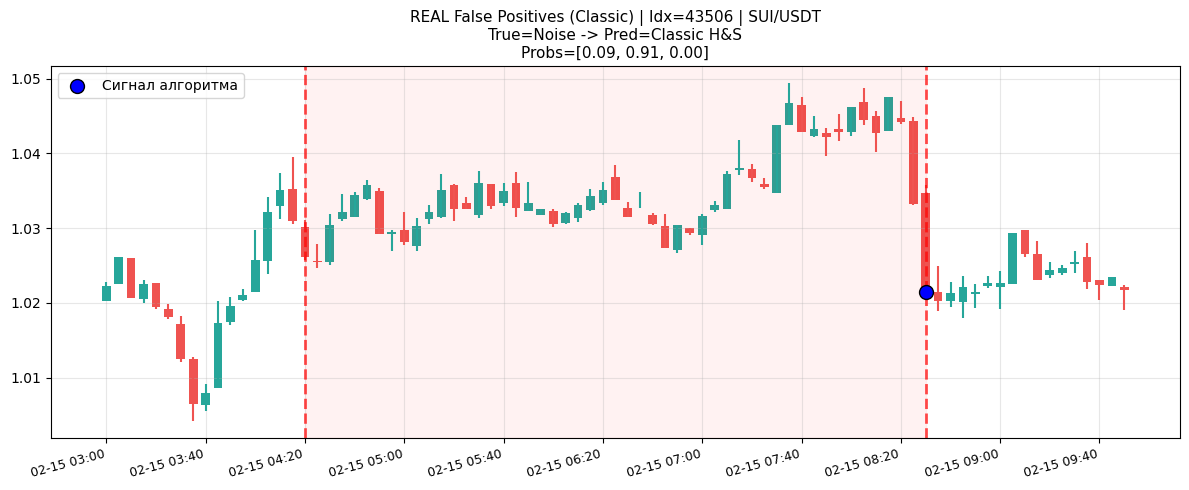

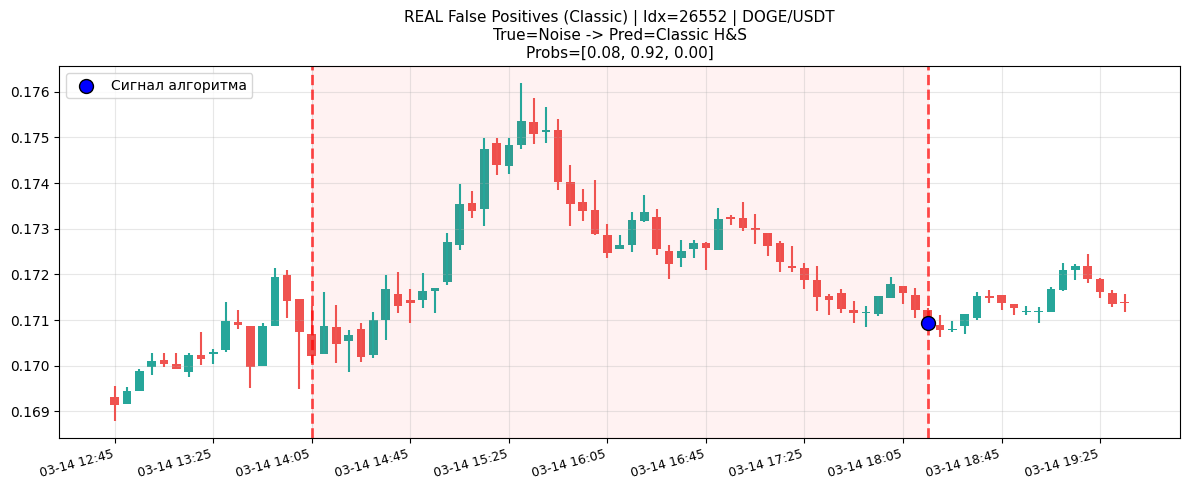

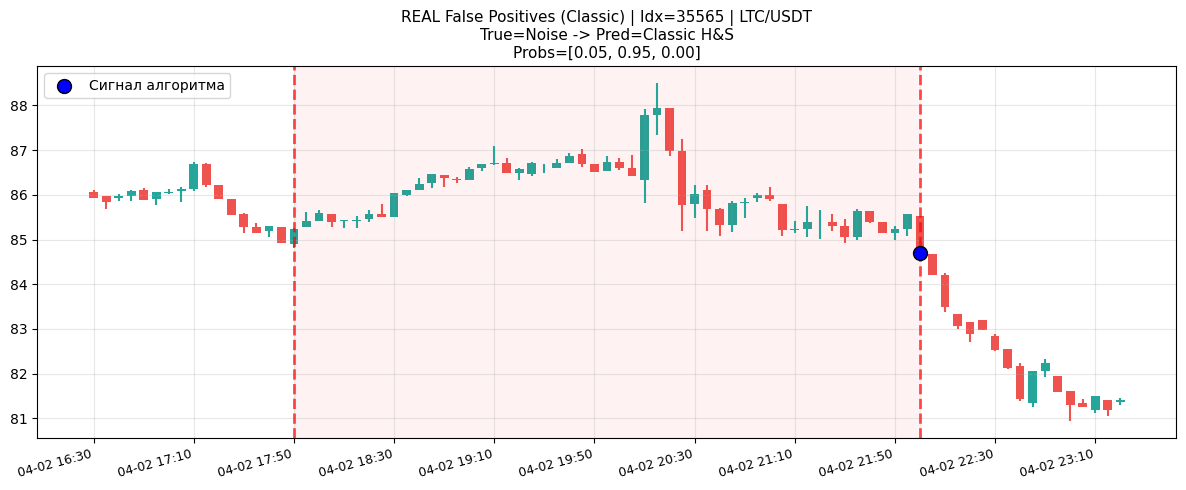

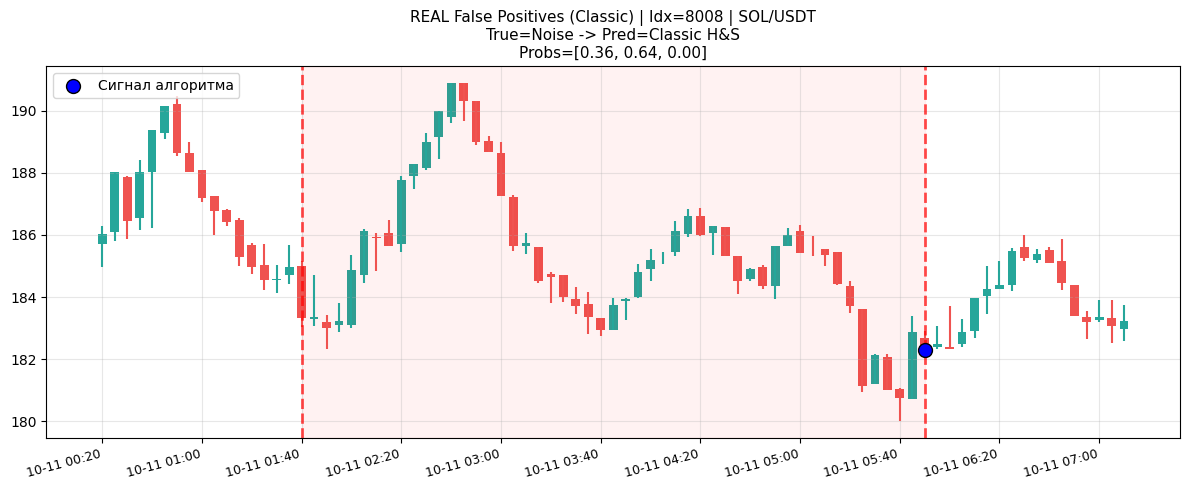

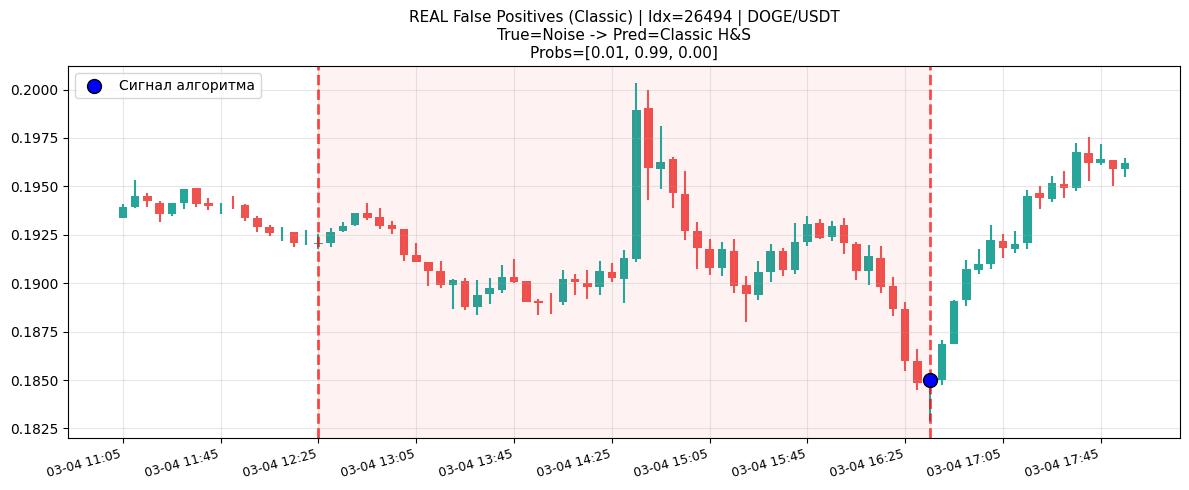


=== Visual debug: ❌ НАСТОЯЩИЕ False Positives Inverse H&S (Найдено: 340) ===


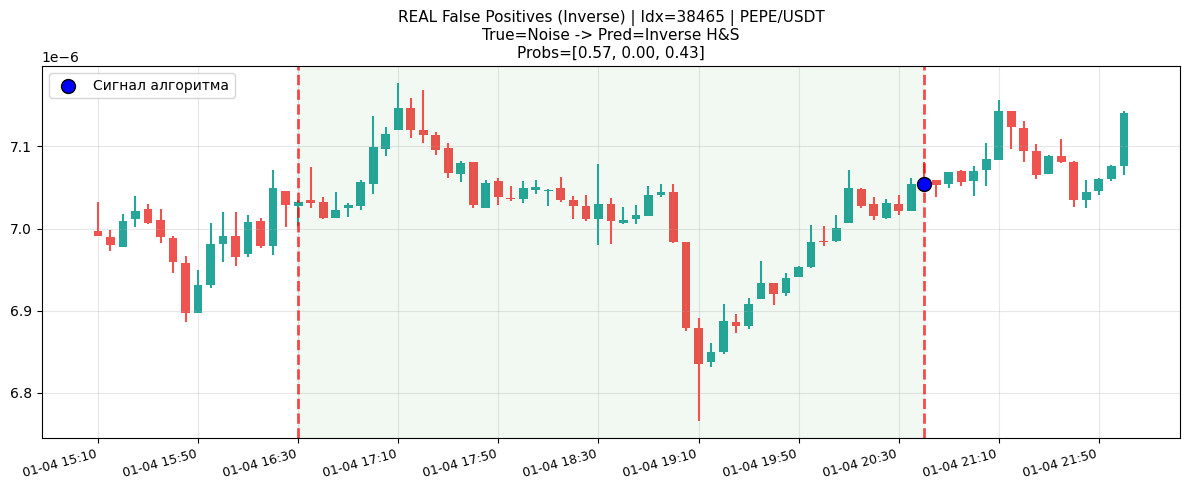

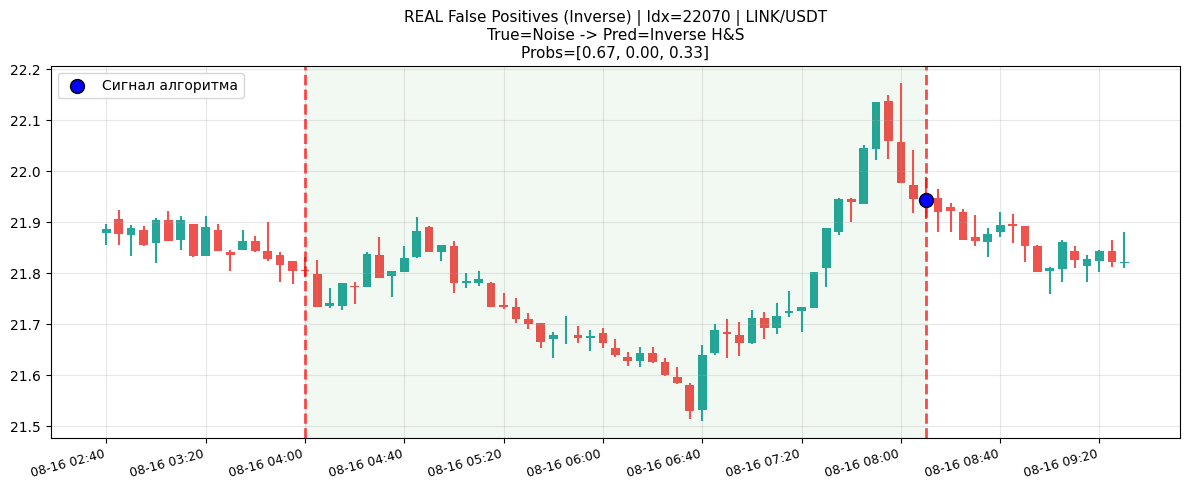

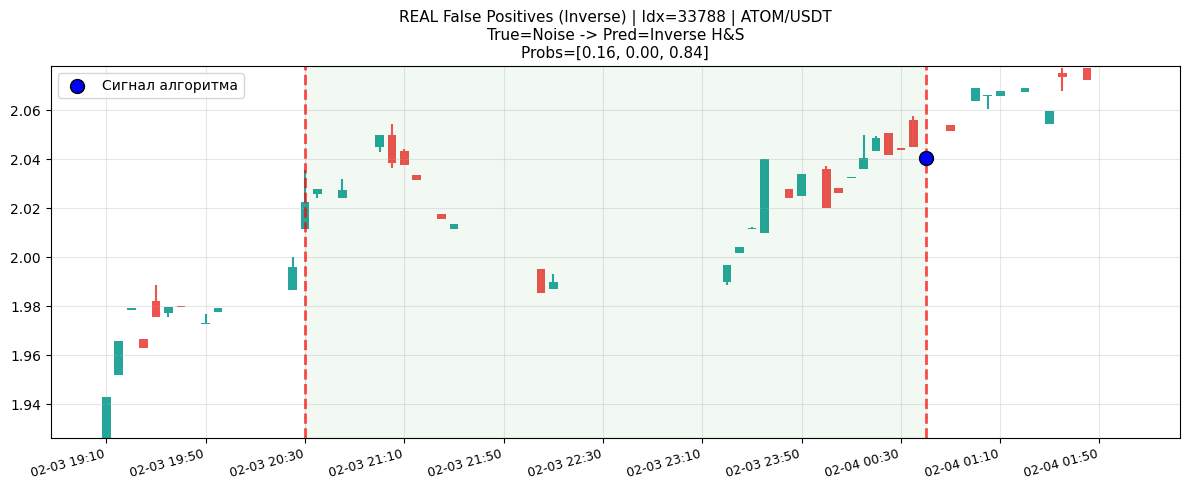

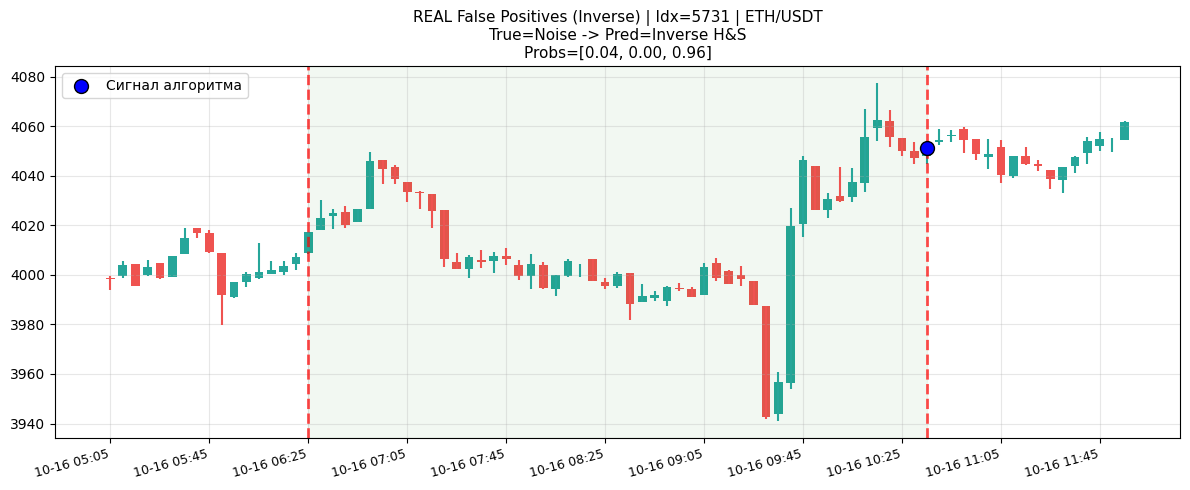

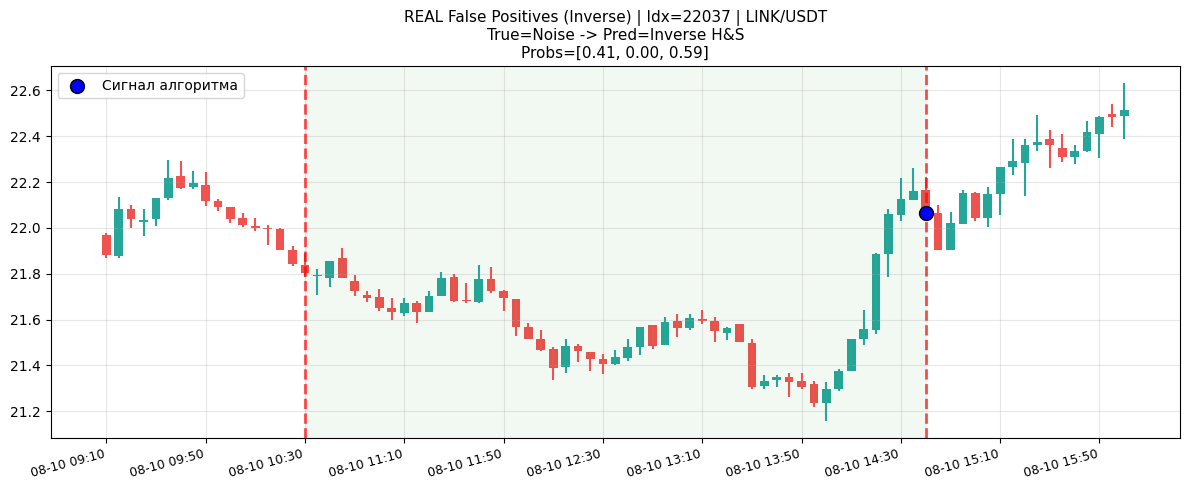


=== Visual debug: ❌ НАСТОЯЩИЕ False Negative Classic H&S (Найдено: 15) ===


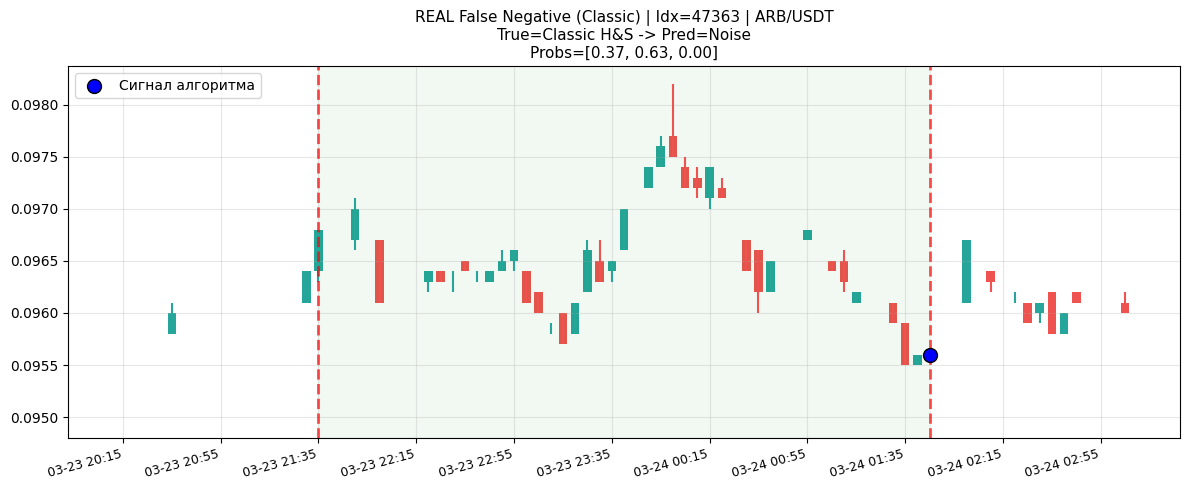

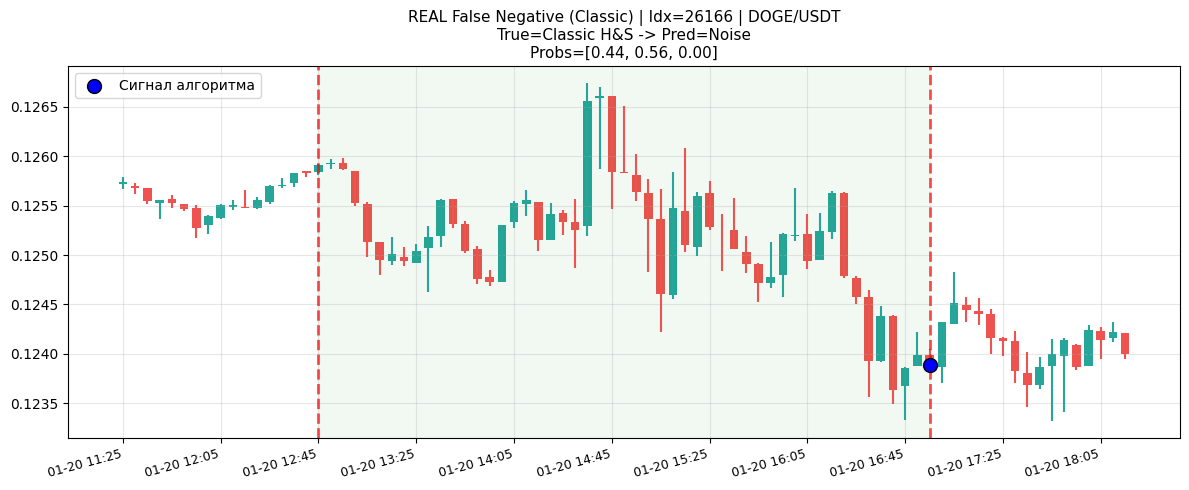

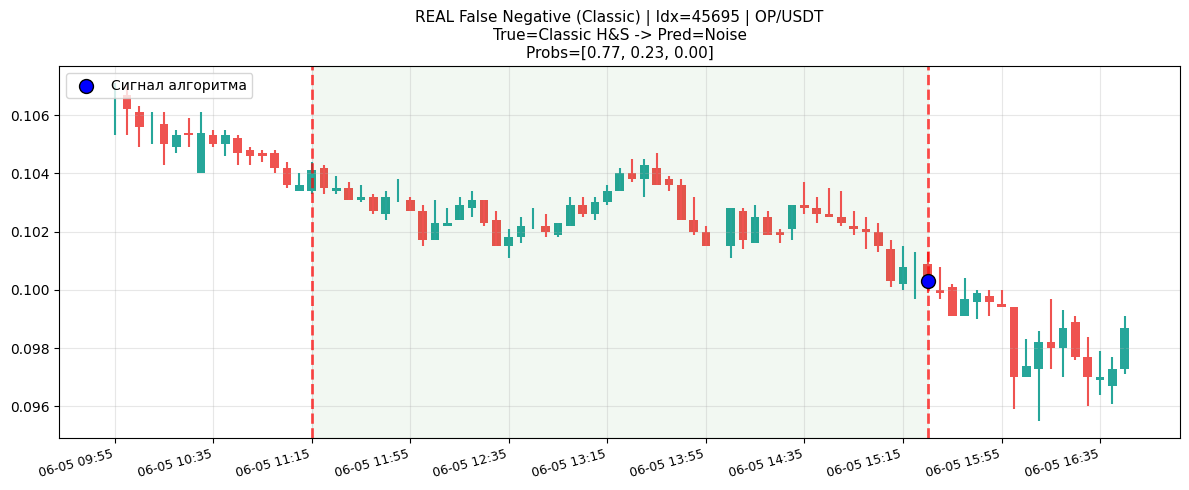

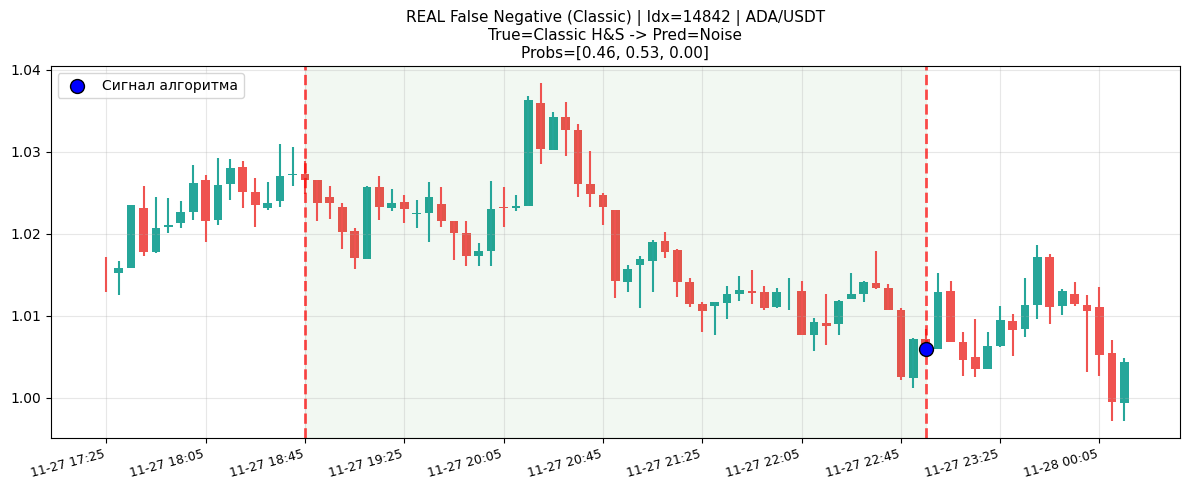

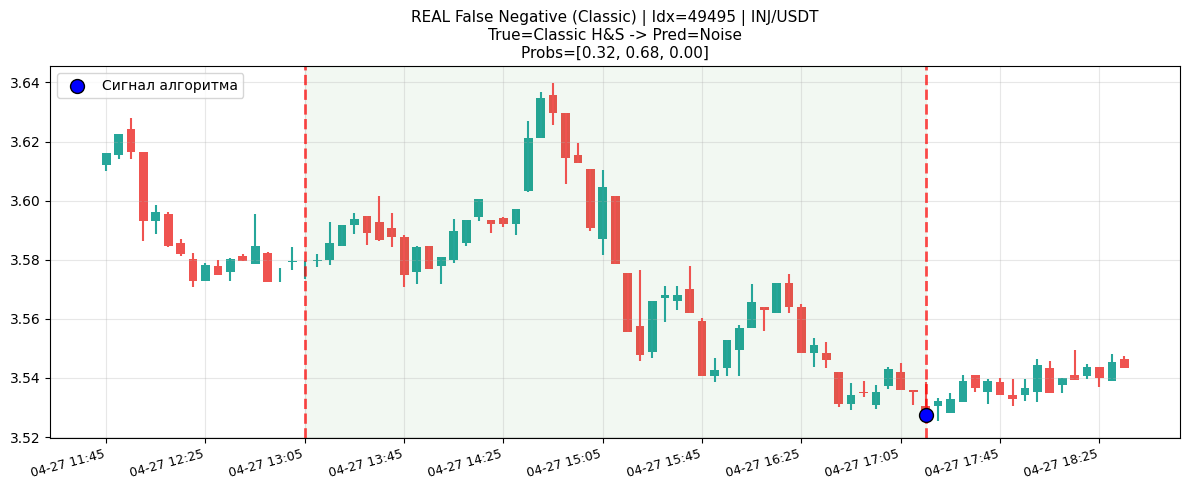


=== Visual debug: ❌ НАСТОЯЩИЕ False Negative Inverse H&S (Найдено: 19) ===


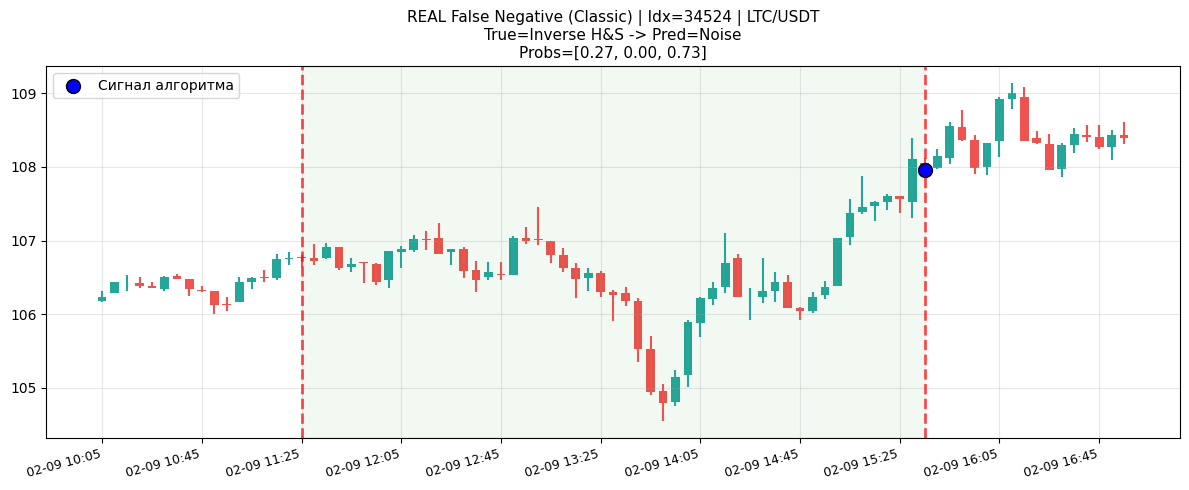

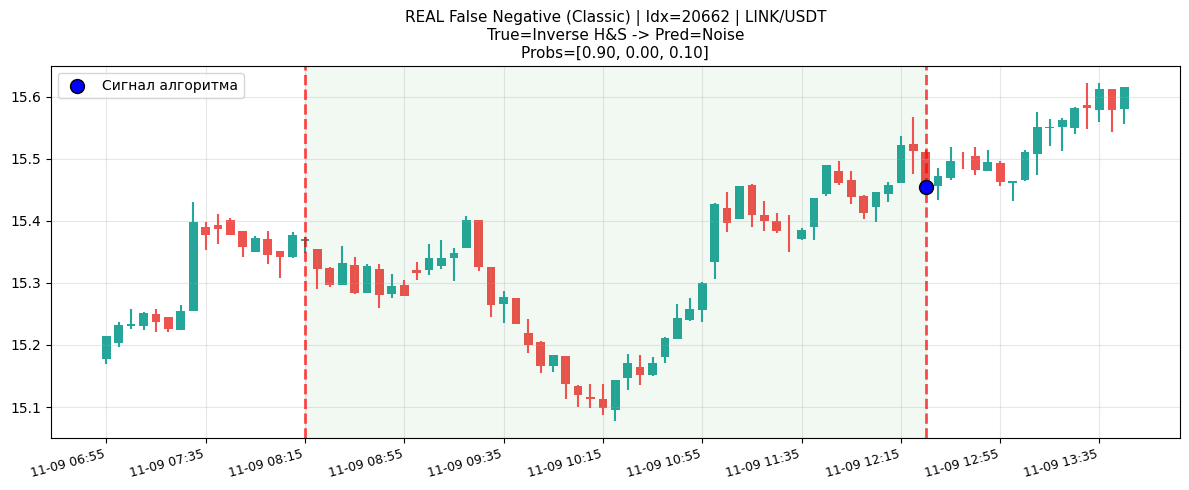

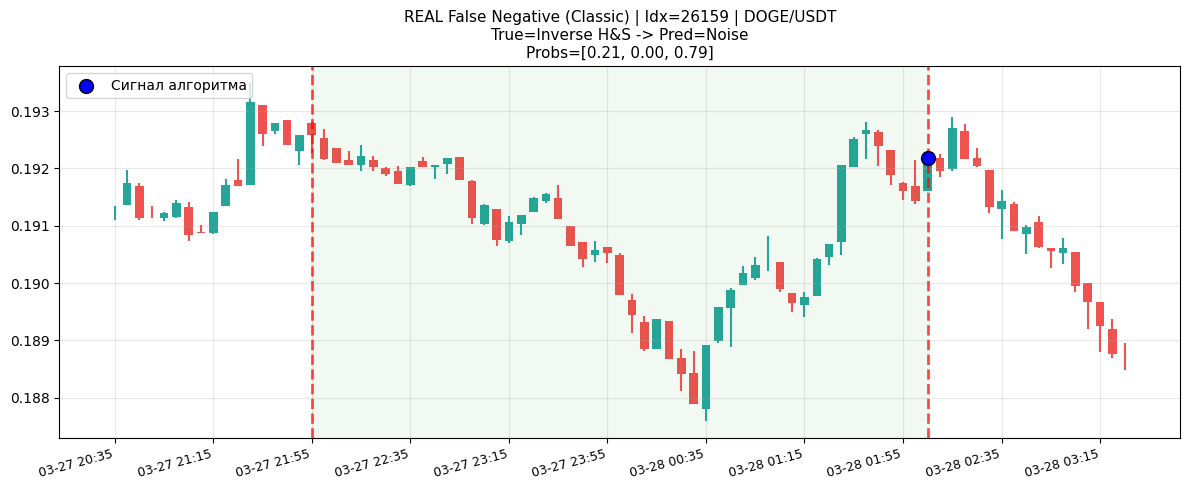

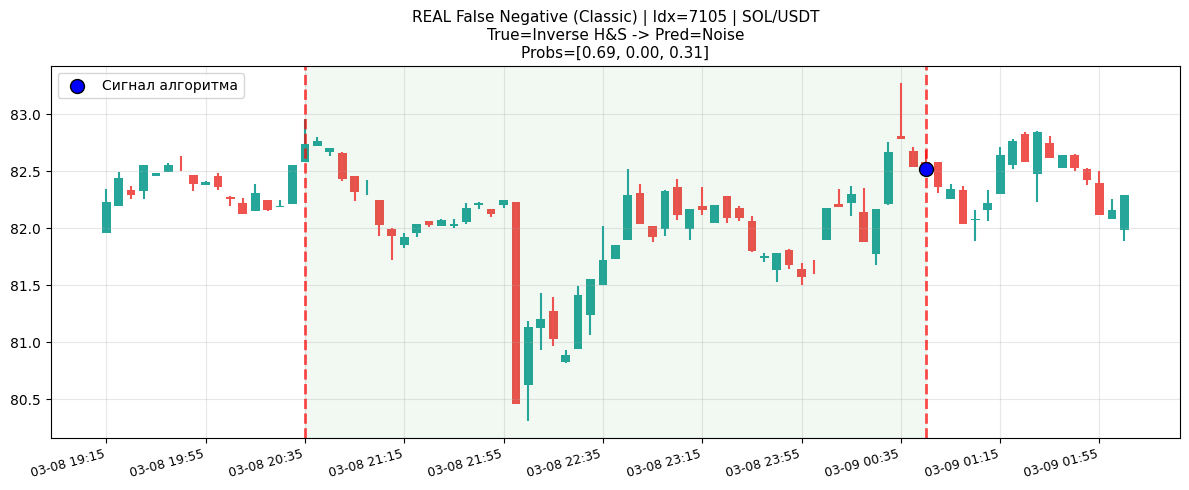

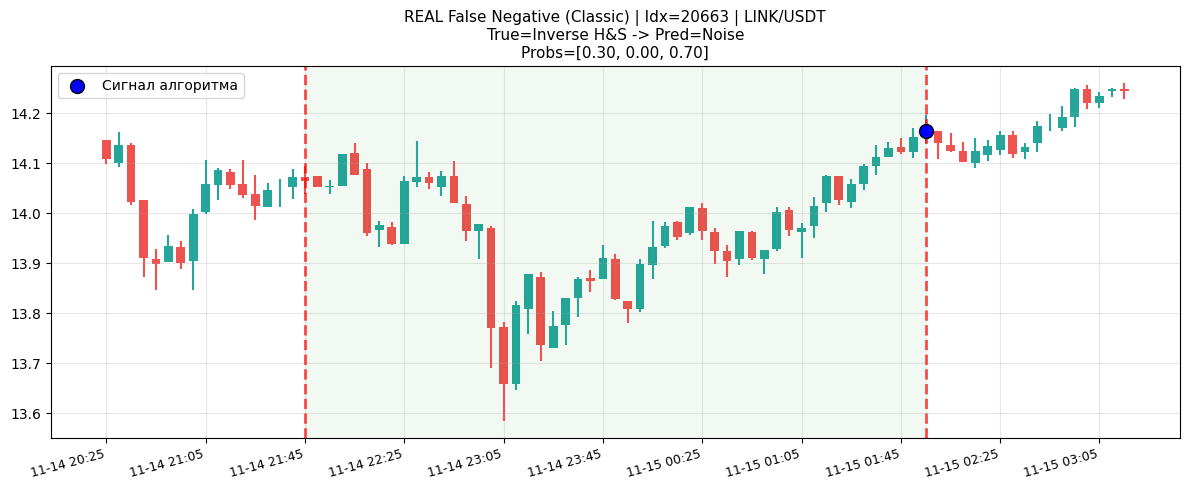

In [40]:
# Apply NMS to the final Sniper results only
y_pred_test = apply_nms_clustering(y_pred_cascade, probas_cascade, window_size=30)

print('🔍 Classification report for the Two-Stage Cascade after NMS:')
print(classification_report(y_test, y_pred_test, labels=[0, 1, 2], target_names=['Noise', 'Classic H&S', 'Inverse H&S']))

smart_metrics_df = evaluate_with_tolerance(y_test, y_pred_test, tolerance=3)
print_ascii_report(smart_metrics_df)

tp_1, fp_1, fn_1 = get_tolerant_indices(y_test, y_pred_test, class_idx=1, tolerance=3)
tp_2, fp_2, fn_2 = get_tolerant_indices(y_test, y_pred_test, class_idx=2, tolerance=3)

print(f'
=== Visual debug: ❌ REAL False Positives Classic H&S (Found: {len(fp_1)}) ===')
plot_prediction_charts(fp_1, meta_test, test_all_data, probas_cascade, y_test, y_pred_test, title='REAL False Positives (Classic)', window_size=pattern_length, num_charts=5)

print(f'
=== Visual debug: ❌ REAL False Positives Inverse H&S (Found: {len(fp_2)}) ===')
plot_prediction_charts(fp_2, meta_test, test_all_data, probas_cascade, y_test, y_pred_test, title='REAL False Positives (Inverse)', window_size=pattern_length, num_charts=5)

print(f'
=== Visual debug: ❌ REAL False Negatives Classic H&S (Found: {len(fn_1)}) ===')
plot_prediction_charts(fn_1, meta_test, test_all_data, probas_cascade, y_test, y_pred_test, title='REAL False Negative (Classic)', window_size=pattern_length, num_charts=5)

print(f'
=== Visual debug: ❌ REAL False Negatives Inverse H&S (Found: {len(fn_2)}) ===')
plot_prediction_charts(fn_2, meta_test, test_all_data, probas_cascade, y_test, y_pred_test, title='REAL False Negative (Inverse)', window_size=pattern_length, num_charts=5)


# Saving model

In [ ]:
path_to_model_weights_dir = '/content/drive/MyDrive/Crypto_pattern_detection_models'

In [ ]:
# SaveThisModel
os.makedirs(path_to_model_weights_dir, exist_ok=True)
best_xgb_model.save_model(f"{path_to_model_weights_dir}/xgb_hs_detector.json")

In [ ]:
# loadModel
best_xgb_model = xgb.XGBClassifier()
best_xgb_model.load_model(f"{path_to_model_weights_dir}/xgb_hs_detector.json")